In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import tifffile
from skimage.measure import regionprops_table
import random
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage
import seaborn as sns
import umap
import igraph as ig
import leidenalg
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import networkx as nx
import igraph as ig
import leidenalg
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial import cKDTree
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
# Acquisition pixel sizes (microns).
XY_UM = 0.1893014
Z_UM = 0.7996567
#### xy pixel size = 0.1893014, z pixel size = 0.7996567

In [6]:
directory = Path(r"z:\Jorge\SPACEFISH_analysis\2026\v121-vascu-rep1\results")
folders = []
for folder in directory.iterdir():
    if folder.is_dir():
        folders.append(folder)
folders_to_read = [f for f in folders if "noamp" not in f.name and "noim" not in f.name]
output_dir = Path(r"c:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish")
# output_dir.mkdir(parents=True, exist_ok=True)


In [3]:
def centroids_from_mask(mask: np.ndarray):
    """Return (props_df, (Xmax, Ymax, Zmax)). Mask assumed (Z, Y, X) if 3D."""
    mask = np.squeeze(mask)
    props = pd.DataFrame(regionprops_table(mask, properties=("label", "centroid")))
    # if mask.ndim == 3:
    props = props.rename(columns={
        "centroid-0": "nucleus_centroid_z",
        "centroid-1": "nucleus_centroid_y",
        "centroid-2": "nucleus_centroid_x",
    })
    zmax, ymax, xmax = mask.shape
    # else:  # 2D fallback
    #     props = props.rename(columns={
    #         "centroid-0": "nucleus_centroid_y",
    #         "centroid-1": "nucleus_centroid_x",
    #     })
    #     props["nucleus_centroid_z"] = np.nan
    #     ymax, xmax = mask.shape
    #     zmax = 1
    return props, (int(xmax), int(ymax), int(zmax))

In [17]:
def check_one(folder: Path):
    """ Check we can use the NucleiLocation.csv data rather than reading in the segmentation mask each time
    Values of 0 mean the mask matches the csv data
    """
    seg_path = next(iter(folder.glob("*seg_mask.tif*")), None)
    xyz_path = next(iter(folder.glob("*NucleiLocation*.csv")), None)
    if seg_path is None or not xyz_path.exists():
        print("File Missing")
        return None

    mask = np.squeeze(tifffile.imread(str(seg_path)))
    props, (xmax, ymax, zmax) = centroids_from_mask(mask)
    props = props.rename(columns={"label": "nucleus"})

    xyz = pd.read_csv(xyz_path).rename(columns={"ID": "nucleus"})
    m = props.merge(xyz, on="nucleus", how="inner")

    # direct mapping (centroid_x vs xyz.x, etc.)
    dx = (m["nucleus_centroid_x"] - m["x"]).abs().round(3)
    dy = (m["nucleus_centroid_y"] - m["y"]).abs().round(3)
    dz = (m["nucleus_centroid_z"] - m["z"]).abs().round(3)
    return {
        "folder": folder.name,
        "mask_shape_ZYX": mask.shape,
        "n_matched": len(m),
        "max_dx": dx.max(), "max_dy": dy.max(), "max_dz": dz.max(),
        "mean_dx": dx.mean(), "mean_dy": dy.mean(), "mean_dz": dz.mean(),
    }

test = folders_to_read[1]
report = pd.DataFrame([check_one(test)])


In [18]:
def source_root_name(folder: Path) -> str:
    """Name of the top-level root in folders_to_read that contains this folder."""
    rp = folder.resolve()
    for root in folders_to_read:
        rr = root.resolve()
        if rp == rr or rr in rp.parents:
            return root.name
    return "UNKNOWN"

def mask_extent(seg_path: Path):
    """Read only the array shape (no pixel data) -> (Xmax, Ymax, Zmax)."""
    shape = tifffile.TiffFile(str(seg_path)).series[0].shape
    zmax, ymax, xmax = tuple(s for s in shape if s > 1)  # drop singleton axes
    return int(xmax), int(ymax), int(zmax)

all_tables = []

for folder in folders_to_read:
    print(folder)
    count_csv = next(iter(folder.glob("*count_table*.csv")), None)
    seg_path = next(iter(folder.glob("*seg_mask.tif")), None)
    xyz_path = next(iter(folder.glob("*NucleiLocation*.csv")), None)

    if seg_path is None:
        print(f"[SKIP - no seg_mask] {folder}")
        continue
    if not xyz_path.exists():
        print(f"[SKIP - no nucleus_xyz.csv] {folder}")
        continue
    if not count_csv.exists():
        print(f"[SKIP - no count_table.csv] {folder}")
        continue

    df = pd.read_csv(count_csv)

    # Centroids from nucleus_xyz.csv (fast). NOTE: validated x<->y swap vs seg_mask.
    xyz = pd.read_csv(xyz_path).rename(columns={
        "ID": "nucleus",
        "x": "nucleus_centroid_y",   # csv 'x' is image row (Y)
        "y": "nucleus_centroid_x",   # csv 'y' is image column (X)
        "z": "nucleus_centroid_z",
    })[["nucleus", "nucleus_centroid_x", "nucleus_centroid_y", "nucleus_centroid_z"]]
    df = df.merge(xyz, on="nucleus", how="left")

    # Extent from mask header only (no full load).
    xmax, ymax, zmax = mask_extent(seg_path)
    df["Xmax"], df["Ymax"], df["Zmax"] = xmax, ymax, zmax

    # Provenance: which root folder this image came from.
    df.insert(0, "source_folder", source_root_name(folder))

    out_name = f"{folder.name}_count_table_xyz.csv"
    df.to_csv(output_dir / out_name, index=False)
    all_tables.append(df)
    print(f"[OK] {folder.name} [{df['source_folder'].iloc[0]}]: "
          f"{len(df)} nuclei, extent (X,Y,Z)=({xmax},{ymax},{zmax})")

# Concatenate every nucleus from every image into one table.
if all_tables:
    combined = pd.concat(all_tables, ignore_index=True)
    combined.to_csv(output_dir / "all_nuclei.csv", index=False)
    print(f"\nCombined table: {combined.shape[0]} nuclei x {combined.shape[1]} columns")
    print(f"Saved -> {output_dir / 'all_nuclei.csv'}")
else:
    print("\nNo folders produced output.")


z:\Jorge\SPACEFISH_analysis\2026\v121-vascu-rep1\results\dev10_1_day2
[OK] dev10_1_day2 [dev10_1_day2]: 459 nuclei, extent (X,Y,Z)=(3915,3940,126)
z:\Jorge\SPACEFISH_analysis\2026\v121-vascu-rep1\results\dev10_2_day4
[OK] dev10_2_day4 [dev10_2_day4]: 949 nuclei, extent (X,Y,Z)=(5807,3934,251)
z:\Jorge\SPACEFISH_analysis\2026\v121-vascu-rep1\results\dev10_3_day2
[OK] dev10_3_day2 [dev10_3_day2]: 1195 nuclei, extent (X,Y,Z)=(3933,3899,126)
z:\Jorge\SPACEFISH_analysis\2026\v121-vascu-rep1\results\dev10_4_day2
[OK] dev10_4_day2 [dev10_4_day2]: 957 nuclei, extent (X,Y,Z)=(5741,5642,126)
z:\Jorge\SPACEFISH_analysis\2026\v121-vascu-rep1\results\dev10_4_day4
[OK] dev10_4_day4 [dev10_4_day4]: 878 nuclei, extent (X,Y,Z)=(3939,3937,126)
z:\Jorge\SPACEFISH_analysis\2026\v121-vascu-rep1\results\dev4_1_6h
[OK] dev4_1_6h [dev4_1_6h]: 1504 nuclei, extent (X,Y,Z)=(3933,3906,126)
z:\Jorge\SPACEFISH_analysis\2026\v121-vascu-rep1\results\dev4_2_6h
[OK] dev4_2_6h [dev4_2_6h]: 1262 nuclei, extent (X,Y,Z)=(3

# Read Gene Counts
- iterate through folders and extract counts
- define cells as endothelilal/fibroblast/unknown
- restrict to cells with spots, and with gene IDs that occur in >3 cells

In [20]:
combined = pd.read_csv(output_dir / "all_nuclei.csv")

In [21]:
combined["epithelial_score"] = combined[["CDH5", "PECAM1", "VWF", "KDR", "FLT1" , "PDGFB"]].sum(axis=1)
combined["fibroblast_score"] = combined[["PDGFRB", "COL1A1", "COL1A2"]].sum(axis=1)
combined["cell_type"] = combined.apply(
    lambda row: "epithelial" if row["epithelial_score"] > row["fibroblast_score"] 
        else "unknown" if row["epithelial_score"] == 0 and row["fibroblast_score"] == 0
        else "fibroblast",
    axis=1
)
combined.head()

,source_folder,name,nucleus,CDH5,MMP1,COL1A1,KDR,VWF,PECAM1,VEGFA,...,FP4col15,nucleus_centroid_x,nucleus_centroid_y,nucleus_centroid_z,Xmax,Ymax,Zmax,epithelial_score,fibroblast_score,cell_type
0,dev10_1_day2,dev10_1_day2,1,0,0,0,0,0,0,0,...,0,188.658333,96.013889,76.424074,3915,3940,126,0,0,unknown
1,dev10_1_day2,dev10_1_day2,2,1,0,0,0,0,0,0,...,0,846.045038,291.633028,78.258132,3915,3940,126,1,0,epithelial
2,dev10_1_day2,dev10_1_day2,3,1,0,0,0,0,0,0,...,0,52.089172,149.869182,76.745958,3915,3940,126,1,0,epithelial
3,dev10_1_day2,dev10_1_day2,5,0,0,0,0,0,0,0,...,0,278.323219,1281.867414,75.916887,3915,3940,126,0,0,unknown
4,dev10_1_day2,dev10_1_day2,6,0,0,0,2,0,0,0,...,0,334.438947,1340.122905,77.061852,3915,3940,126,2,0,epithelial


In [22]:
# Tidy matrix: genes are either on (1+ counts) or off (0 counts). Drop FP readouts and create a readable gene state for on genes (e.g. 1_4_12)
metadata_cols = {
    "name", "source_folder", "nucleus",
    "nucleus_centroid_x", "nucleus_centroid_y", "nucleus_centroid_z", 
    "Xmax", "Ymax", "Zmax", "cell_type", "epithelial_score", "fibroblast_score",
    "state_code",  # derived label columns, not genes
}
gene_columns = [c for c in combined.columns if c not in metadata_cols]
fp_columns = [c for c in gene_columns if c.startswith("FP")]
true_gene_columns = [c for c in gene_columns if not c.startswith("FP")]

combined[true_gene_columns] = (combined[true_gene_columns].fillna(0).astype(float) > 0).astype(int)
combined["state_code"] = combined[true_gene_columns].apply(
    lambda row: "_".join(str(i + 1) for i, value in enumerate(row) if value == 1), axis=1,
).replace("", "0")  # all-negative cells get the code "0"
true_gene_dictionary = {c: i for i, c in enumerate(true_gene_columns)}

# # binary_state: one digit per gene in column order, e.g. "100100000001000000"
combined["binary_state"] = combined[true_gene_columns].astype(str).agg("".join, axis=1)

In [23]:
true_gene_dictionary

{'CDH5': 0,
 'MMP1': 1,
 'COL1A1': 2,
 'KDR': 3,
 'VWF': 4,
 'PECAM1': 5,
 'VEGFA': 6,
 'DLL4': 7,
 'ITGA6': 8,
 'SEMA3F': 9,
 'JAG1': 10,
 'FLT1': 11,
 'PDGFB': 12,
 'COL1A2': 13,
 'APLN': 14,
 'PDGFRB': 15,
 'ANGPT2': 16,
 'ICAM1': 17}

In [24]:
# Keep biologically informative cells and recurrent states.
min_cells_per_state = 3                       # states must occur in > 2 cells
cells_with_spots = combined[combined["binary_state"] != "0" * len(true_gene_columns)].copy()  # drop all-negative cells (no transcripts detected -> not interesting)

In [25]:
state_counts = cells_with_spots["state_code"].value_counts()
recurrent_states = state_counts[state_counts >= min_cells_per_state].index
df_recurrent = cells_with_spots[cells_with_spots["state_code"].isin(recurrent_states)].copy()

n_total = len(combined)
print(f"All cells:                         {n_total:,}")
print(f"Cells with >=1 transcript:         {len(cells_with_spots):,} ({100*len(cells_with_spots)/n_total:.1f}%)")
print(f"Unique expressed states:           {state_counts.size:,}")
print(f"Recurrent states (> 2 cells):      {len(recurrent_states):,}")
print(f"Cells in recurrent states:         {len(df_recurrent):,} ({100*len(df_recurrent)/n_total:.1f}%)")

All cells:                         13,047
Cells with >=1 transcript:         9,472 (72.6%)
Unique expressed states:           1,555
Recurrent states (> 2 cells):      394
Cells in recurrent states:         8,058 (61.8%)


# Spatial & genetic subpopulation analysis

Everything below operates on **`df_recurrent`** - cells with **>=1 transcript** that
fall in a **recurrent gene state** (a state seen in >=3 cells). The *Initial Data
Exploration* section and all cells beneath it are left untouched.

**Coordinates** are converted to microns using the acquisition pixel sizes
(xy = 0.1893014 um, z = 0.7996567 um), and every spatial calculation is performed
*within each image* (`source_folder`) so neighbourhoods never span different images.

**Roadmap**
1. **Pairwise gene interactions** - all cells, then epithelial and fibroblast separately.
2. **Gene states -> cell states** - hierarchical clustering, UMAP, Leiden, and a
   Bernoulli mixture model, comparing an unsupervised vs a probabilistic view so we can
   trust the structure is biological rather than an artefact of one algorithm.
3. **Neighbourhood analysis** - per-cell micro-environment (composition, nearby
   expression, Shannon diversity, density), then clustering neighbourhoods into niches.
4. **Graph-based approaches** - a spatial cell graph (communities + neighbour
   enrichment) and a gene-state graph (states linked when they differ by one gene).

## 0. Setup - analysis frame & physical coordinates


In [26]:
# ============================================================================
# SETUP - build the analysis frame from df_recurrent (cells with >=1 transcript
# in a recurrent gene state) and attach PHYSICAL coordinates.
# ============================================================================
# All analysis below operates only on df_recurrent, as requested. Spatial work is
# done in microns and *within each image* (grouped by source_folder), because each
# image has its own coordinate origin - neighbours must never cross images.


GENES = list(true_gene_columns)      # the 18 real genes (FP channels excluded)
IMAGE_KEY = "source_folder"          # one physical image per source_folder

# Working frame + physical coordinates.
df = df_recurrent.copy().reset_index(drop=True)
df["x_um"] = df["nucleus_centroid_x"] * XY_UM
df["y_um"] = df["nucleus_centroid_y"] * XY_UM
df["z_um"] = df["nucleus_centroid_z"] * Z_UM

# Binary gene matrix (cells x genes) reused throughout.
X = df[GENES].astype(int).to_numpy()

# Consistent colours for the three cell types.
CT_ORDER = ["epithelial", "fibroblast", "unknown"]
CT_COLORS = {"epithelial": "#d62728", "fibroblast": "#1f77b4", "unknown": "#7f7f7f"}

print("\nCell-type counts:")
print(df["cell_type"].value_counts())



Cell-type counts:
cell_type
epithelial    6173
unknown       1200
fibroblast     685
Name: count, dtype: int64


## 1. Pairwise gene interactions

Which genes tend to switch on together, and which are mutually exclusive? For every gene
pair we build a 2x2 on/off contingency table, compute the odds ratio, and test it with
**Fisher's exact test** (Benjamini-Hochberg FDR). We look at all recurrent cells first,
then repeat **separately for epithelial and fibroblast cells**, since co-expression
programmes are expected to differ by lineage.


In [30]:
# Pairwise gene co-occurrence via Fisher's exact test.
# log2 OR > 0 -> genes cooccur more than expected
# log2 OR < 0 -> genes are mutually exclusive

# added cutoffs for more biologically meaningful results:
# mask any pair where a gene is on in <min_pos cells and only trust a negative when n1n2/N > 1 (i.e. we don't just see no cooccurrent because both genes are rare)
def pairwise_cooccurrence(binary_df, genes, title="", ax=None,
                          min_pos=20, min_expected=1.0):
    """Pairwise gene co-occurrence via Fisher's exact test.

    min_pos       : a gene must be ON in >= this many cells for the pair to be shown
                    (otherwise the odds ratio is unstable).
    min_expected  : a NEGATIVE (mutually exclusive) call is only kept when the
                    expected overlap n1*n2/N >= this; below it there is no power
                    to detect depletion, so it is masked.
    """
    N = len(binary_df)
    present = {g: int((binary_df[g] == 1).sum()) for g in genes}
    rows = []
    for i, g1 in enumerate(genes):
        for g2 in genes[i + 1:]:
            a = int(((binary_df[g1] == 1) & (binary_df[g2] == 1)).sum())
            b = int(((binary_df[g1] == 1) & (binary_df[g2] == 0)).sum())
            c = int(((binary_df[g1] == 0) & (binary_df[g2] == 1)).sum())
            d = int(((binary_df[g1] == 0) & (binary_df[g2] == 0)).sum())
            odds = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
            _, p = fisher_exact([[a, b], [c, d]])
            expected = present[g1] * present[g2] / N   # overlap expected if independent
            rows.append(dict(gene1=g1, gene2=g2, both=a, odds_ratio=odds, pvalue=p,
                             n1=present[g1], n2=present[g2], expected=expected))
    res = pd.DataFrame(rows)
    res["FDR"] = multipletests(res.pvalue, method="fdr_bh")[1]
    res["log2_OR"] = np.log2(res.odds_ratio)

    # A pair is "testable" only if both genes clear the marginal cutoff.
    res["testable"] = (res.n1 >= min_pos) & (res.n2 >= min_pos)
    # Exclusivity (negative OR) additionally needs a detectable expected overlap.
    res["exclusivity_reliable"] = res.testable & (res.expected >= min_expected)

    M = pd.DataFrame(np.nan, index=genes, columns=genes)
    for _, r in res.iterrows():
        if not r.testable:
            continue                      # too few positives -> leave blank
        if r.log2_OR < 0 and not r.exclusivity_reliable:
            continue                      # can't trust a "mutually exclusive" call
        M.loc[r.gene1, r.gene2] = r.log2_OR
        M.loc[r.gene2, r.gene1] = r.log2_OR


    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))   # only make a figure if none passed
    lim = np.nanmax(np.abs(M.values)) if np.isfinite(M.values).any() else 1.0
    sns.heatmap(M, cmap="coolwarm", center=0, vmin=-lim, vmax=lim, square=True,
                mask=M.isna(), ax=ax, cbar_kws={"label": "log2 odds ratio"})
    ax.set_title(title)
    return res, M

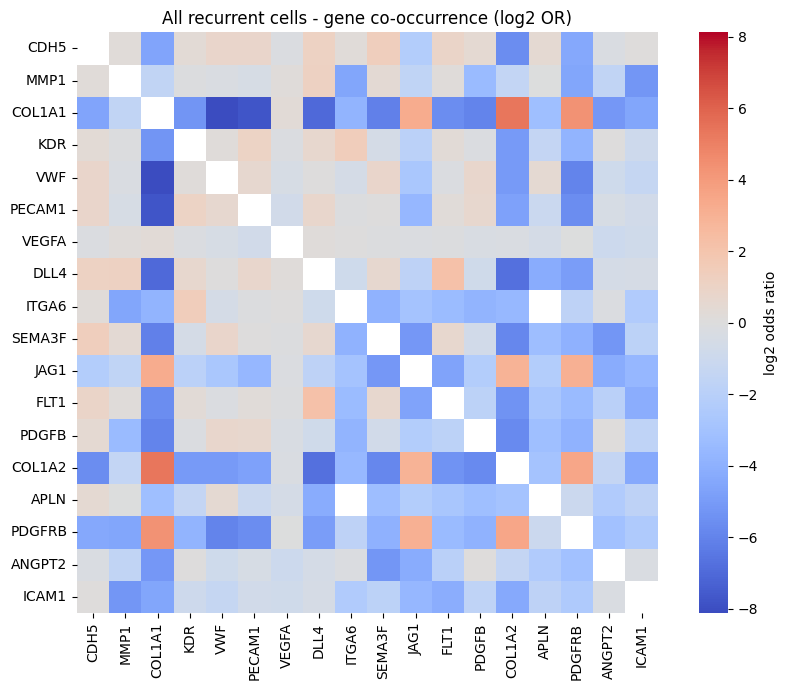

Significant pairs (FDR<0.05): 101  (co-occurring: 25, exclusive: 76)

Strongest co-occurring gene pairs:


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
43,COL1A1,COL1A2,479,409,236,24.312609,41.461569,5.373703,7.511182e-200
45,COL1A1,PDGFRB,479,115,61,6.836064,20.291704,4.342818,1.204266e-43
144,COL1A2,PDGFRB,409,115,41,5.837056,11.451586,3.517475,8.283800e-24
40,COL1A1,JAG1,479,259,87,15.396004,9.573064,3.258981,9.290638e-43
129,JAG1,PDGFRB,259,115,23,3.696327,8.279584,3.049558,5.249089e-12
127,JAG1,COL1A2,259,409,67,13.146066,7.634942,2.932617,2.308318e-29
101,DLL4,FLT1,903,361,122,40.454579,4.526765,2.178480,8.575480e-31
52,KDR,ITGA6,2913,112,67,40.488459,2.658238,1.410471,1.342808e-06
8,CDH5,SEMA3F,4082,504,362,255.314966,2.621806,1.390561,2.041793e-22
22,MMP1,DLL4,734,903,152,82.253909,2.290032,1.195368,1.994038e-14


Strongest mutually-exclusive gene pairs:


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
34,COL1A1,VWF,479,1702,0,101.173740,0.003600,-8.117839,4.639328e-50
35,COL1A1,PECAM1,479,1408,0,83.697195,0.004569,-7.773925,1.222824e-40
37,COL1A1,DLL4,479,903,0,53.677960,0.007706,-7.019892,4.886818e-25
103,DLL4,COL1A2,903,409,0,45.833582,0.009117,-6.777177,1.956655e-21
39,COL1A1,SEMA3F,479,504,0,29.959792,0.014624,-6.095481,1.204973e-13
42,COL1A1,PDGFB,479,473,0,28.117027,0.015650,-5.997684,1.056428e-12
72,VWF,PDGFRB,1702,115,0,24.290146,0.015870,-5.977511,7.864744e-12
120,SEMA3F,COL1A2,504,409,0,25.581534,0.017294,-5.853611,1.193533e-11
138,PDGFB,COL1A2,473,409,0,24.008067,0.018506,-5.755876,6.469966e-11
84,PECAM1,PDGFRB,1408,115,0,20.094316,0.020087,-5.637611,1.629209e-09


In [33]:
# --- All recurrent cells ------------------------------------------------------------
res_all, M_all = pairwise_cooccurrence(
    df, GENES, title="All recurrent cells - gene co-occurrence (log2 OR)")
plt.tight_layout(); plt.show()

# Readable labels for the summary tables.
show_cols = {
    "gene1": "gene1", "gene2": "gene2",
    "n1": "# cells gene1 on", "n2": "# cells gene2 on",
    "both": "# overlap (both on)", "expected": "# overlap expected",
    "odds_ratio": "odds_ratio", "log2_OR": "log2_OR", "FDR": "FDR",
}
cols = list(show_cols)

sig = res_all[res_all.FDR < 0.05].copy()
print(f"Significant pairs (FDR<0.05): {len(sig)}  "
      f"(co-occurring: {(sig.log2_OR > 0).sum()}, exclusive: {(sig.log2_OR < 0).sum()})")
print("\nStrongest co-occurring gene pairs:")
display(sig.sort_values("log2_OR", ascending=False).head(10)[cols].rename(columns=show_cols))
print("Strongest mutually-exclusive gene pairs:")
display(sig.sort_values("log2_OR").head(10)[cols].rename(columns=show_cols))

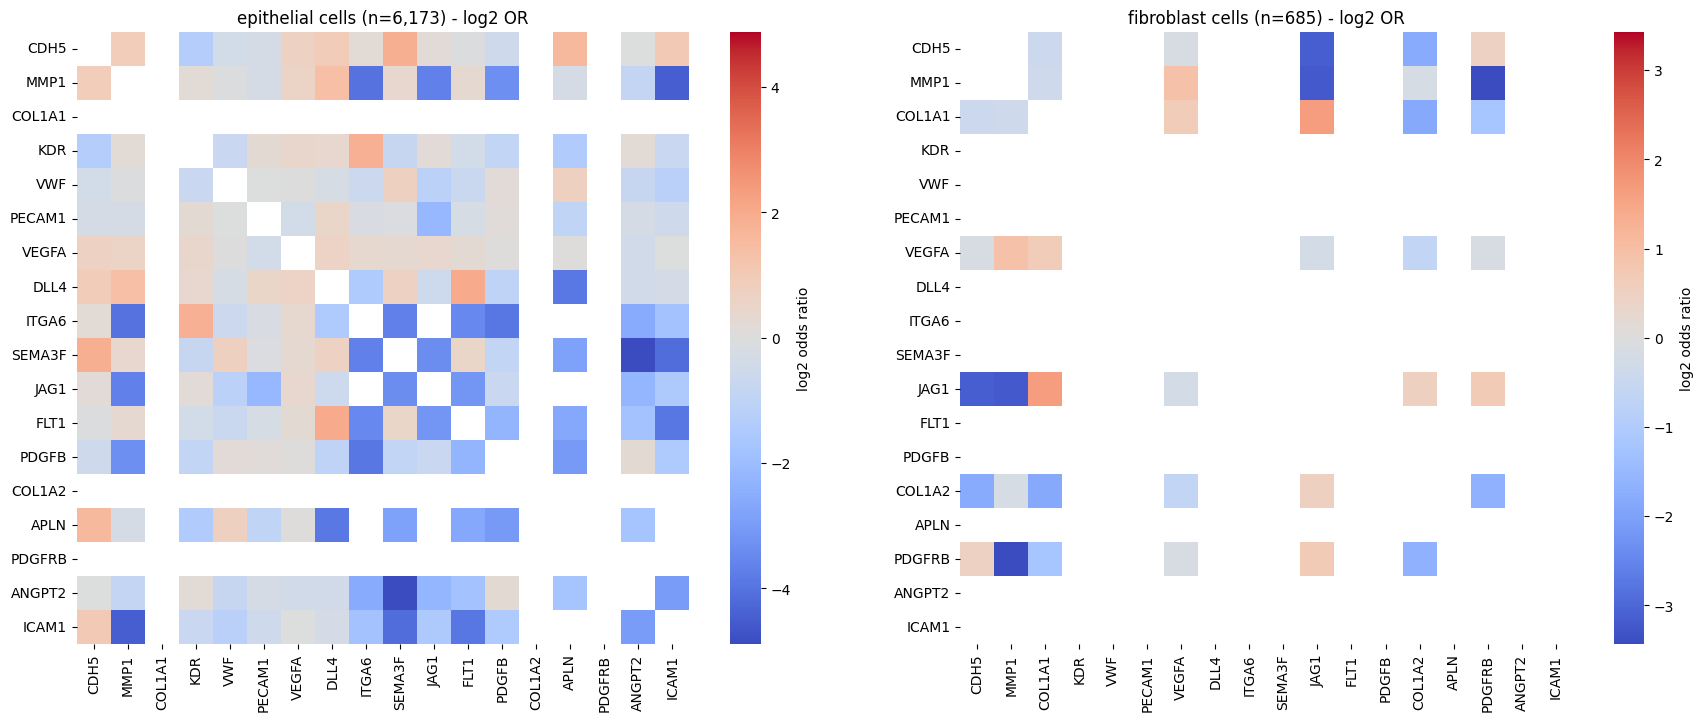

In [40]:
# --- Split by cell type: do the interaction patterns differ by lineage? -------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
pair_by_type = {}
all_res = []
for ax, label in zip(axes, ["epithelial", "fibroblast"]):
    sub = df[df.cell_type == label]
    res, _ = pairwise_cooccurrence(sub, GENES, ax=ax,
                                   title=f"{label} cells (n={len(sub):,}) - log2 OR")
    pair_by_type[label] = res
    all_res.append(res.assign(cell_type=label))
plt.tight_layout(); plt.show()

# Which pairs behave most differently between epithelial and fibroblast cells?
# merged = pair_by_type["epithelial"].merge(
#     pair_by_type["fibroblast"], on=["gene1", "gene2"], suffixes=("_epi", "_fib"))
# merged["delta_log2OR"] = merged["log2_OR_epi"] - merged["log2_OR_fib"]
# print("Largest cell-type differences in co-occurrence (epithelial - fibroblast):")
# cols2 = ["gene1", "gene2",
#          "n1_epi", "n2_epi", "both_epi",     # epithelial: gene1 on / gene2 on / overlap
#          "n1_fib", "n2_fib", "both_fib",     # fibroblast: gene1 on / gene2 on / overlap
#          "log2_OR_epi", "log2_OR_fib", "delta_log2OR"]
# display(merged.reindex(merged.delta_log2OR.abs().sort_values(ascending=False).index)
#         .head(12)[cols2])



In [42]:
for res, label in zip(all_res, ["epithelial", "fibroblast"]):
    sig = res[res.FDR < 0.05].copy()
    print(f"Significant {label} pairs (FDR<0.05): {len(sig)}  "
        f"(co-occurring: {(sig.log2_OR > 0).sum()}, exclusive: {(sig.log2_OR < 0).sum()})")
    print("\nStrongest co-occurring gene pairs:")
    display(sig.sort_values("log2_OR", ascending=False).head(10)[cols].rename(columns=show_cols))
    print(f"Strongest mutually-exclusive {label} gene pairs:")
    display(sig.sort_values("log2_OR").head(10)[cols].rename(columns=show_cols))

Significant epithelial pairs (FDR<0.05): 50  (co-occurring: 17, exclusive: 33)

Strongest co-occurring gene pairs:


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
101,DLL4,FLT1,783,361,122,45.790215,3.983221,1.993936,2.981139e-25
8,CDH5,SEMA3F,4058,416,362,273.469626,3.709404,1.891187,1.632358e-22
52,KDR,ITGA6,2901,88,67,41.355581,3.601410,1.848562,3.997400e-07
13,CDH5,APLN,4058,49,42,32.211566,2.974771,1.572778,9.159438e-03
22,MMP1,DLL4,513,783,130,65.070306,2.607477,1.382655,9.243806e-15
16,CDH5,ICAM1,4058,119,95,78.228090,2.056915,1.040482,4.200726e-03
6,CDH5,DLL4,4058,783,607,514.727685,1.934120,0.951678,5.726063e-13
0,CDH5,MMP1,4058,513,398,337.235380,1.885578,0.915007,2.143139e-08
66,VWF,SEMA3F,1702,416,157,114.698202,1.654299,0.726220,2.651859e-05
5,CDH5,VEGFA,4058,2099,1529,1379.838328,1.638054,0.711983,5.437530e-16


Strongest mutually-exclusive epithelial gene pairs:


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
123,SEMA3F,ANGPT2,416,197,0,13.275879,0.033799,-4.886883,0.000015
32,MMP1,ICAM1,513,119,0,9.889357,0.045153,-4.469026,0.000435
124,SEMA3F,ICAM1,416,119,0,8.019439,0.056644,-4.141944,0.003080
23,MMP1,ITGA6,513,88,0,7.313138,0.061311,-4.027717,0.003791
137,FLT1,ICAM1,361,119,0,6.959177,0.065898,-3.923619,0.005820
111,ITGA6,PDGFB,88,473,0,6.742913,0.066967,-3.900398,0.007474
104,DLL4,APLN,783,49,0,6.215292,0.068863,-3.860117,0.008317
108,ITGA6,SEMA3F,88,416,0,5.930342,0.076905,-3.700772,0.015022
25,MMP1,JAG1,513,70,0,5.817269,0.077213,-3.695010,0.014114
110,ITGA6,FLT1,88,361,0,5.146282,0.089466,-3.482523,0.032758


Significant fibroblast pairs (FDR<0.05): 4  (co-occurring: 1, exclusive: 3)

Strongest co-occurring gene pairs:


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
40,COL1A1,JAG1,472,101,87,69.594161,3.122904,1.642888,1.206089e-03
45,COL1A1,PDGFRB,472,115,61,79.240876,0.437391,-1.193006,3.771364e-03
144,COL1A2,PDGFRB,403,115,41,67.656934,0.320398,-1.642063,3.456332e-06
43,COL1A1,COL1A2,472,403,236,277.687591,0.277612,-1.848858,1.669346e-10


Strongest mutually-exclusive fibroblast gene pairs:


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
43,COL1A1,COL1A2,472,403,236,277.687591,0.277612,-1.848858,1.669346e-10
144,COL1A2,PDGFRB,403,115,41,67.656934,0.320398,-1.642063,3.456332e-06
45,COL1A1,PDGFRB,472,115,61,79.240876,0.437391,-1.193006,3.771364e-03
40,COL1A1,JAG1,472,101,87,69.594161,3.122904,1.642888,1.206089e-03


## 2. Which gene states define distinct cell states?

We compare several ways of grouping cells by their 18-gene on/off pattern, **split by
cell type**:

| Approach | Type | Idea |
|---|---|---|
| Hierarchical (Hamming) | unsupervised | agglomerate similar gene states |
| Leiden on kNN graph | unsupervised | communities in a gene-similarity graph |
| UMAP | visualisation | 2-D embedding of the same graph |
| Bernoulli mixture | probabilistic | generative on/off model, K chosen by BIC |

Agreement between an **unsupervised** method (Leiden / hierarchical) and the
**probabilistic** Bernoulli mixture - measured with the Adjusted Rand Index - tells us
the structure is robust, i.e. real biology rather than an artefact of one clustering
choice.


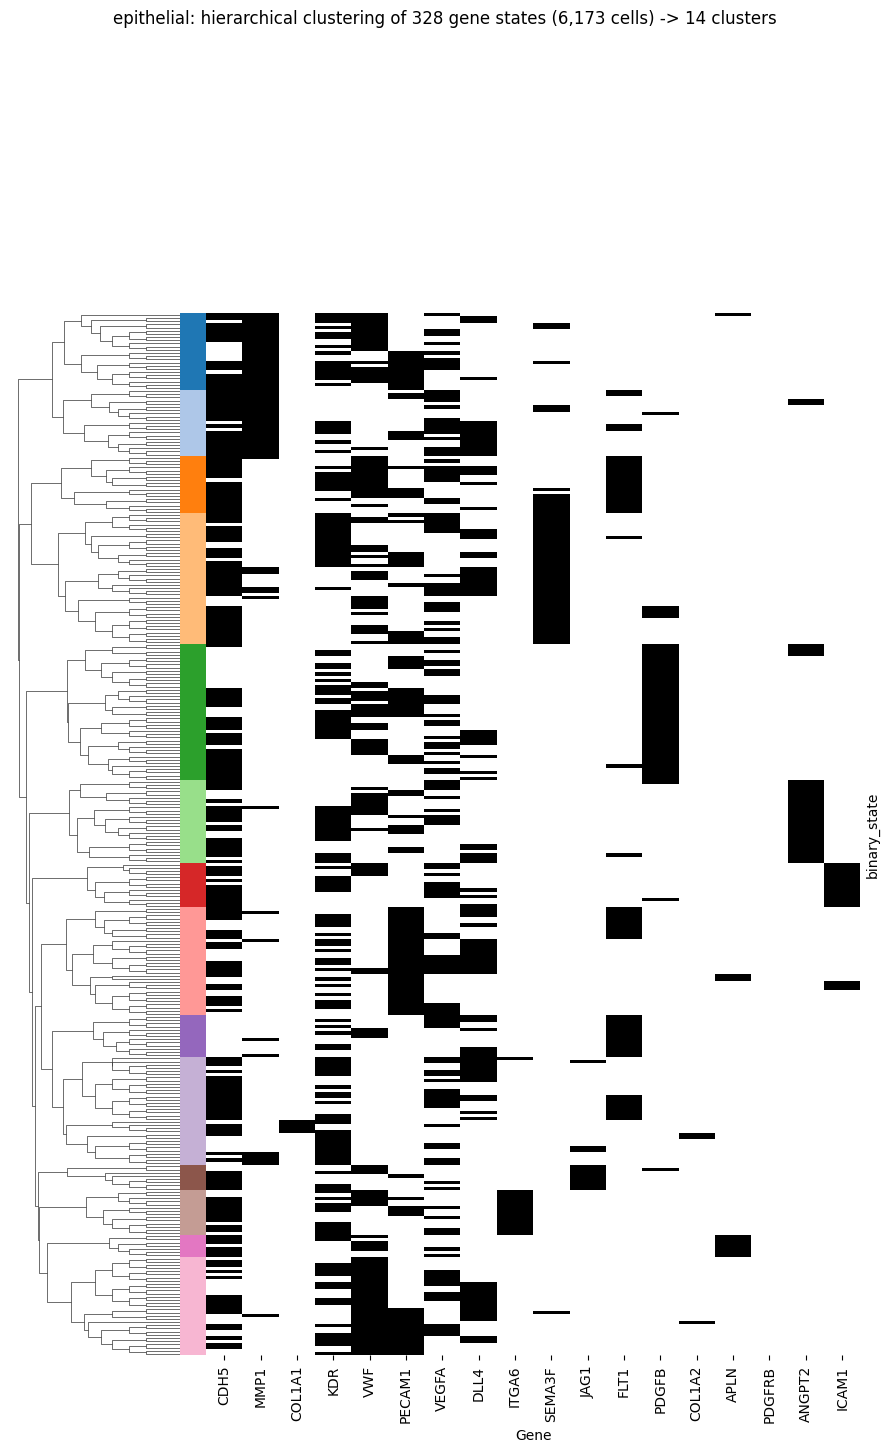

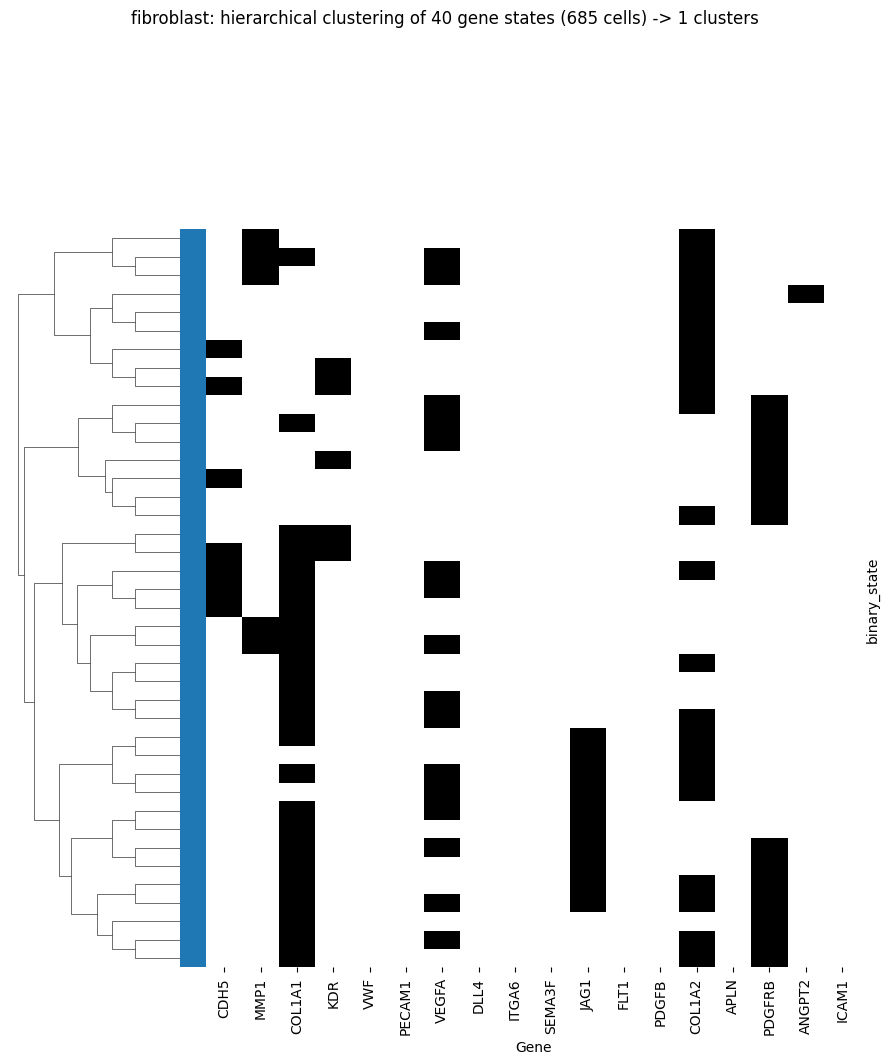

,cell_type,hier_cluster,state_code,genes_on,n_cells,pct_within_cell_type
66,epithelial,1,1_2_4_6,"CDH5, MMP1, KDR, PECAM1",15,0.242994
70,epithelial,1,1_2_5_7,"CDH5, MMP1, VWF, VEGFA",14,0.226794
81,epithelial,1,1_2_4_5_7,"CDH5, MMP1, KDR, VWF, VEGFA",12,0.194395
83,epithelial,1,1_2_4_5,"CDH5, MMP1, KDR, VWF",12,0.194395
84,epithelial,1,1_2_4_6_7,"CDH5, MMP1, KDR, PECAM1, VEGFA",12,0.194395
105,epithelial,1,2_4_5,"MMP1, KDR, VWF",9,0.145796
106,epithelial,1,2_5,"MMP1, VWF",9,0.145796
122,epithelial,1,1_2_5,"CDH5, MMP1, VWF",8,0.129597
141,epithelial,1,1_2_4_5_6,"CDH5, MMP1, KDR, VWF, PECAM1",7,0.113397
162,epithelial,1,2_5_7,"MMP1, VWF, VEGFA",6,0.097197


In [30]:
# Hierarchical clustering of the *gene states* (unique 18-bit vectors), done separately
# per cell type. Rows = states, columns = genes; row colours flag the clusters cut from
# the dendrogram. Clustering states (not individual cells) keeps the plot readable and
# directly answers "which gene states group together".

def state_matrix(sub):
    counts = sub.groupby("binary_state").size().sort_values(ascending=False)
    mat = pd.DataFrame([[int(ch) for ch in bs] for bs in counts.index],
                       index=counts.index, columns=GENES)
    return mat, counts

def binary_to_state_code(bs):
    """'100100100...' -> readable 1-indexed gene code e.g. '1_4_7' ('0' if all off)."""
    genes_on = [str(i + 1) for i, ch in enumerate(bs) if ch == "1"]
    return "_".join(genes_on) if genes_on else "0"

def state_code_to_gene_names(state_code):
    """'1_4_7' -> 'CDH5, KDR, VWF' using the gene order in GENES (1-indexed)."""
    if state_code == "0":
        return "none"
    return ", ".join(GENES[int(p) - 1] for p in state_code.split("_"))

hier_state_clusters = {}
cluster_rows = []
for label in ["epithelial", "fibroblast"]:
    sub = df[df.cell_type == label]
    mat, counts = state_matrix(sub)
    if len(mat) < 3:
        print(f"{label}: only {len(mat)} states - skipping")
        continue

    Z = linkage(pdist(mat.values, metric="hamming"), method="average")
    cl = fcluster(Z, t=0.2, criterion="distance")
    ser = pd.Series(cl, index=mat.index, name="hier_cluster")
    hier_state_clusters[label] = ser

    # One row per gene state, tagged with its cluster, cell counts and readable genes.
    tmp = (
        ser.to_frame()
        .join(counts.rename("n_cells"))
        .reset_index()
        .rename(columns={"index": "binary_state"})
    )
    tmp["cell_type"] = label
    tmp["pct_within_cell_type"] = 100 * tmp["n_cells"] / tmp["n_cells"].sum()
    tmp["state_code"] = tmp["binary_state"].apply(binary_to_state_code)
    tmp["genes_on"] = tmp["state_code"].apply(state_code_to_gene_names)
    cluster_rows.append(tmp)

    # Clustermap of the gene states, coloured by cluster.
    pal = sns.color_palette("tab20", cl.max())
    row_colors = [pal[c - 1] for c in cl]
    cg = sns.clustermap(mat, row_linkage=Z, col_cluster=False, cmap="Greys",
                        row_colors=row_colors, yticklabels=False, cbar_pos=None,
                        figsize=(9, min(14, 0.18 * len(mat) + 3)))
    cg.ax_heatmap.set_xlabel("Gene")
    cg.figure.suptitle(
        f"{label}: hierarchical clustering of {len(mat)} gene states "
        f"({counts.sum():,} cells) -> {cl.max()} clusters", y=1.02)
    plt.show()

# Full per-state table across both cell types.
cluster_table = pd.concat(cluster_rows, ignore_index=True)
cluster_table = cluster_table[
    ["cell_type", "hier_cluster", "state_code", "genes_on",
     "n_cells", "pct_within_cell_type"]
].sort_values(["cell_type", "hier_cluster", "n_cells"], ascending=[True, True, False])

cluster_table.head(50)


In [32]:
# Readable summary: the main gene states in each (cell type, cluster), with the genes
# each state corresponds to. e.g. "epithelial cluster 1: 42.0% in 1_4_7 (CDH5, KDR, VWF)".
top_states_per_cluster = 5   # how many dominant states to list per cluster

summary_rows = []
grp = cluster_table.groupby(["cell_type", "hier_cluster"], sort=True)
for (label, cluster), g in grp:
    g = g.sort_values("n_cells", ascending=False)
    total = g["n_cells"].sum()
    top = g.head(top_states_per_cluster)

    # % is relative to the cells in THIS cluster.
    parts = [f"{100 * r.n_cells / total:.1f}% in {r.state_code} ({r.genes_on})"
             for r in top.itertuples()]
    summary_rows.append({
        "cell_type": label,
        "hier_cluster": cluster,
        "n_states": len(g),
        "n_cells": int(total),
        "main_states": "; ".join(parts),
    })

cluster_summary = (
    pd.DataFrame(summary_rows)
    .sort_values(["cell_type", "n_cells"], ascending=[True, False])
    .reset_index(drop=True)
)

# Print a human-readable version.
for r in cluster_summary.itertuples():
    print(f"{r.cell_type} cluster {r.hier_cluster} "
          f"({r.n_cells:,} cells, {r.n_states} states): {r.main_states}")

cluster_summary.to_csv("hamming_clustering.csv", index=False)


epithelial cluster 10 (2,434 cells, 34 states): 27.1% in 1 (CDH5); 18.9% in 4 (KDR); 10.7% in 1_4 (CDH5, KDR); 10.6% in 1_7 (CDH5, VEGFA); 7.8% in 1_4_7 (CDH5, KDR, VEGFA)
epithelial cluster 14 (1,139 cells, 31 states): 19.7% in 5 (VWF); 15.5% in 1_5 (CDH5, VWF); 9.7% in 1_5_7 (CDH5, VWF, VEGFA); 7.1% in 1_4_5 (CDH5, KDR, VWF); 6.1% in 4_5 (KDR, VWF)
epithelial cluster 8 (802 cells, 34 states): 14.7% in 1_6 (CDH5, PECAM1); 14.5% in 6 (PECAM1); 11.6% in 4_6 (KDR, PECAM1); 11.6% in 1_4_6 (CDH5, KDR, PECAM1); 7.2% in 1_4_6_7 (CDH5, KDR, PECAM1, VEGFA)
epithelial cluster 5 (442 cells, 43 states): 12.9% in 13 (PDGFB); 8.6% in 1_13 (CDH5, PDGFB); 6.3% in 1_7_13 (CDH5, VEGFA, PDGFB); 5.7% in 7_13 (VEGFA, PDGFB); 4.8% in 4_13 (KDR, PDGFB)
epithelial cluster 4 (362 cells, 41 states): 11.3% in 1_10 (CDH5, SEMA3F); 8.6% in 1_7_10 (CDH5, VEGFA, SEMA3F); 6.6% in 1_5_10 (CDH5, VWF, SEMA3F); 5.5% in 1_4_10 (CDH5, KDR, SEMA3F); 5.0% in 4_10 (KDR, SEMA3F)
epithelial cluster 2 (203 cells, 21 states): 27

In [ ]:
# Full per-state detail, sorted by cluster then frequency.
cluster_table.sort_values(
    ["cell_type", "hier_cluster", "n_cells"], ascending=[True, True, False]
).head(50)


AttributeError: 'DataFrameGroupBy' object has no attribute 'sort_values'

In [17]:
cluster_table[cluster_table.cell_type=="fibroblast"]

,cell_type,hier_cluster,binary_state,state_code,n_cells,pct_within_cell_type
328,fibroblast,1,001000000000010000,3_14,103,15.036496
329,fibroblast,1,001000000000000000,3,79,11.532847
330,fibroblast,1,000000000000010000,14,76,11.094891
331,fibroblast,1,001000100000000000,3_7,76,11.094891
332,fibroblast,1,001000100000010000,3_7_14,55,8.029197
333,fibroblast,1,000000100000010000,7_14,48,7.007299
334,fibroblast,1,000000000000000100,16,26,3.795620
335,fibroblast,1,001000000010010000,3_11_14,26,3.795620
336,fibroblast,1,001000100010000000,3_7_11,15,2.189781
337,fibroblast,1,001000100000000100,3_7_16,14,2.043796


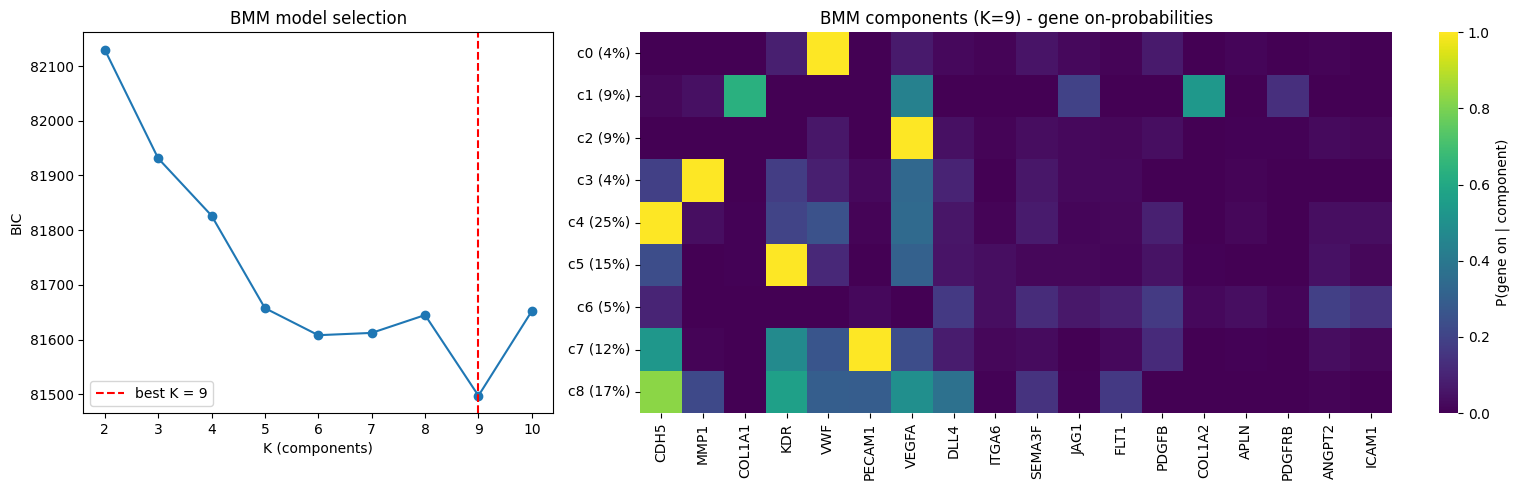

BMM component vs cell type:
cell_type  epithelial  fibroblast  unknown
bmm                                       
0                 281           0        0
1                   0         652       50
2                 105           0      715
3                 136           0      196
4                2435          17        0
5                1037          11        0
6                  98           5      236
7                1076           0        0
8                1005           0        3


In [17]:
# Bernoulli Mixture Model (BMM) - a PROBABILISTIC alternative to distance-based
# clustering. Each latent component k has an independent on-probability p[k, gene]; every
# cell is a soft mixture over components. We fit by EM, pick K by BIC, and read off
# assignments. Because it models the actual on/off generative process, it is a good
# cross-check against Leiden / hierarchical (which use distances only).
class BernoulliMixture:
    def __init__(self, n_components, n_iter=300, tol=1e-6, n_init=8, seed=0):
        self.K, self.n_iter, self.tol, self.n_init, self.seed = (
            n_components, n_iter, tol, n_init, seed)

    def _fit_once(self, X, rng):
        n, d = X.shape
        p = rng.uniform(0.1, 0.9, size=(self.K, d))
        w = np.full(self.K, 1.0 / self.K)
        ll_prev = -np.inf
        R = np.full((n, self.K), 1.0 / self.K)
        for _ in range(self.n_iter):
            logp = (X @ np.log(p.T) + (1 - X) @ np.log(1 - p.T)) + np.log(w)
            m = logp.max(axis=1, keepdims=True)
            lse = m.ravel() + np.log(np.exp(logp - m).sum(axis=1))
            ll = lse.sum()
            R = np.exp(logp - lse[:, None])
            Nk = R.sum(axis=0) + 1e-9
            w = Nk / n
            p = np.clip((R.T @ X) / Nk[:, None], 1e-3, 1 - 1e-3)
            if abs(ll - ll_prev) < self.tol * (abs(ll_prev) + 1e-9):
                break
            ll_prev = ll
        return w, p, ll, R

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        rng = np.random.default_rng(self.seed)
        best = None
        for _ in range(self.n_init):
            cand = self._fit_once(X, rng)
            if best is None or cand[2] > best[2]:
                best = cand
        self.weights_, self.probs_, self.loglik_, self.resp_ = best
        self.labels_ = self.resp_.argmax(axis=1)
        n, d = X.shape
        n_params = self.K * d + (self.K - 1)
        self.bic_ = -2 * self.loglik_ + n_params * np.log(n)
        return self

# Model selection by BIC (lower is better), fit on all recurrent cells.
Ks = list(range(2, 11))
bmm_models = {k: BernoulliMixture(k, seed=0).fit(X) for k in Ks}
bics = pd.Series({k: m.bic_ for k, m in bmm_models.items()})
best_k = int(bics.idxmin())
bmm = bmm_models[best_k]
df["bmm"] = bmm.labels_

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 2]})
axes[0].plot(Ks, bics.values, "o-")
axes[0].axvline(best_k, color="red", ls="--", label=f"best K = {best_k}")
axes[0].set(xlabel="K (components)", ylabel="BIC", title="BMM model selection")
axes[0].legend()
comp = pd.DataFrame(bmm.probs_, columns=GENES,
                    index=[f"c{k} ({w:.0%})" for k, w in enumerate(bmm.weights_)])
sns.heatmap(comp, cmap="viridis", vmin=0, vmax=1, ax=axes[1],
            cbar_kws={"label": "P(gene on | component)"})
axes[1].set_title(f"BMM components (K={best_k}) - gene on-probabilities")
plt.tight_layout(); plt.show()

print("BMM component vs cell type:")
print(pd.crosstab(df["bmm"], df["cell_type"]))


c:\Users\taylorhearn\AppData\Local\miniforge3\envs\sequencing\lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\taylorhearn\AppData\Local\miniforge3\envs\sequencing\lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\taylorhearn\AppData\Local\miniforge3\envs\sequencing\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\taylorhearn\AppData\Local\miniforge3\envs\sequencing\lib\site-packages\pynndescent\pynndescent_.py:1241: UserWarning: Failed to correctly find n_neighbors for some samples. Results may be less than ideal. Try re-running with different parameters.
  warn(


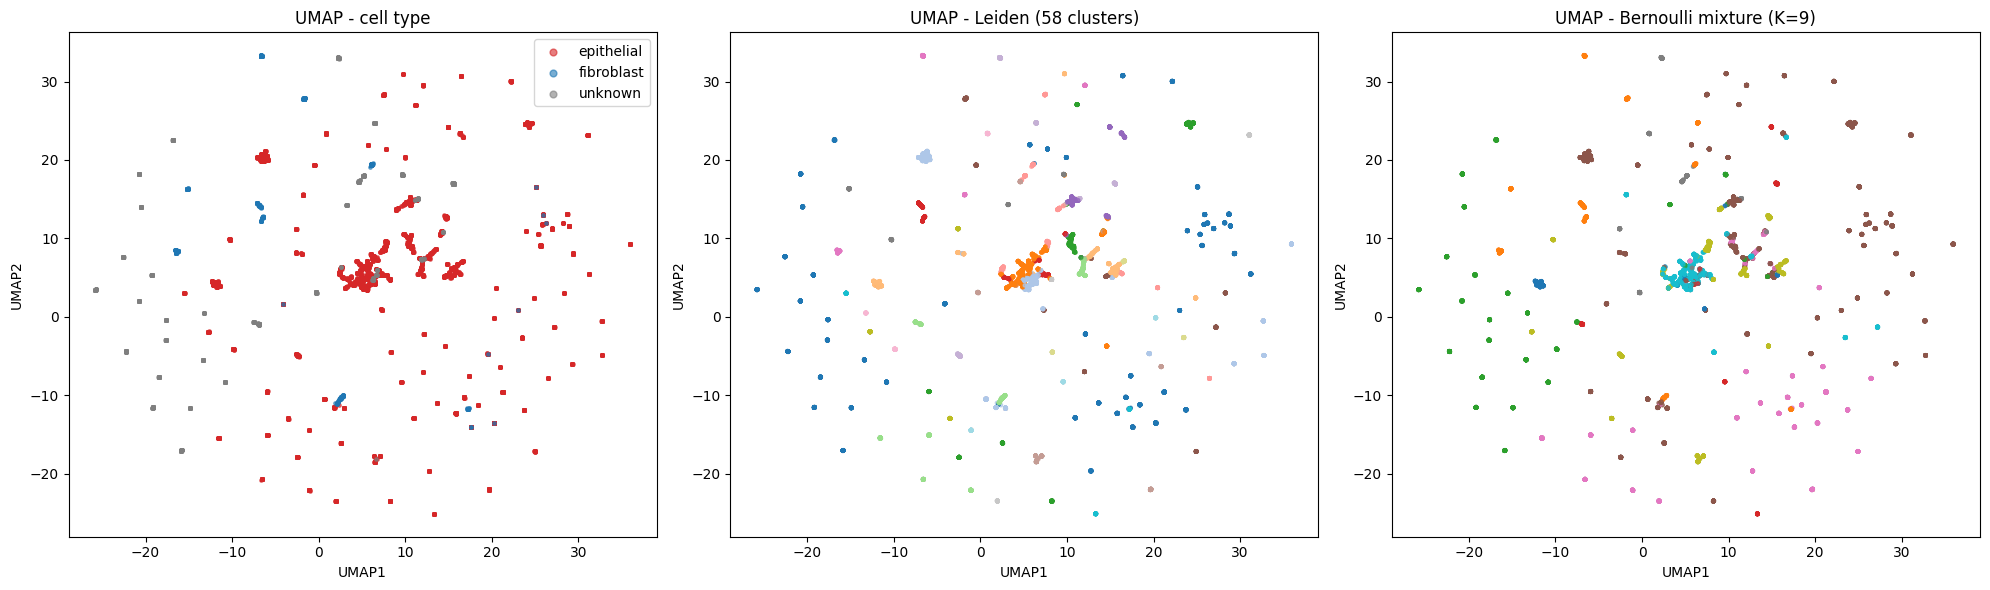

In [ ]:
# UMAP embedding + Leiden clustering - the unsupervised graph view. We build a k-nearest-
# neighbour graph in gene space using the Jaccard metric (natural for sparse binary
# vectors), cluster it with Leiden, and embed the SAME neighbour structure with UMAP.
# Colouring by cell type shows whether transcriptional clusters follow lineage.


k_nn = 15
nn = NearestNeighbors(n_neighbors=k_nn, metric="jaccard").fit(X)
_, idx = nn.kneighbors(X)
edges = {(min(i, int(j)), max(i, int(j)))
         for i in range(idx.shape[0]) for j in idx[i, 1:]}
g_gene = ig.Graph(n=len(X), edges=list(edges))
part = leidenalg.find_partition(g_gene, leidenalg.RBConfigurationVertexPartition,
                                resolution_parameter=1.0, seed=0)
df["leiden"] = np.array(part.membership)

emb = umap.UMAP(metric="jaccard", n_neighbors=k_nn, min_dist=0.1,
                random_state=0).fit_transform(X)
df["umap1"], df["umap2"] = emb[:, 0], emb[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ct in CT_ORDER:
    s = df[df.cell_type == ct]
    axes[0].scatter(s.umap1, s.umap2, s=6, alpha=0.6, label=ct, color=CT_COLORS[ct])
axes[0].legend(markerscale=2); axes[0].set_title("UMAP - cell type")
axes[1].scatter(df.umap1, df.umap2, s=6, alpha=0.7, c=df.leiden, cmap="tab20")
axes[1].set_title(f"UMAP - Leiden ({df.leiden.nunique()} clusters)")
axes[2].scatter(df.umap1, df.umap2, s=6, alpha=0.7, c=df.bmm, cmap="tab10")
axes[2].set_title(f"UMAP - Bernoulli mixture (K={best_k})")
for a in axes:
    a.set_xlabel("UMAP1"); a.set_ylabel("UMAP2")
plt.tight_layout(); plt.show()


Adjusted Rand Index between clusterings:
  leiden vs bmm   : ARI = 0.234
  leiden vs hier  : ARI = 0.197
     bmm vs hier  : ARI = 0.284


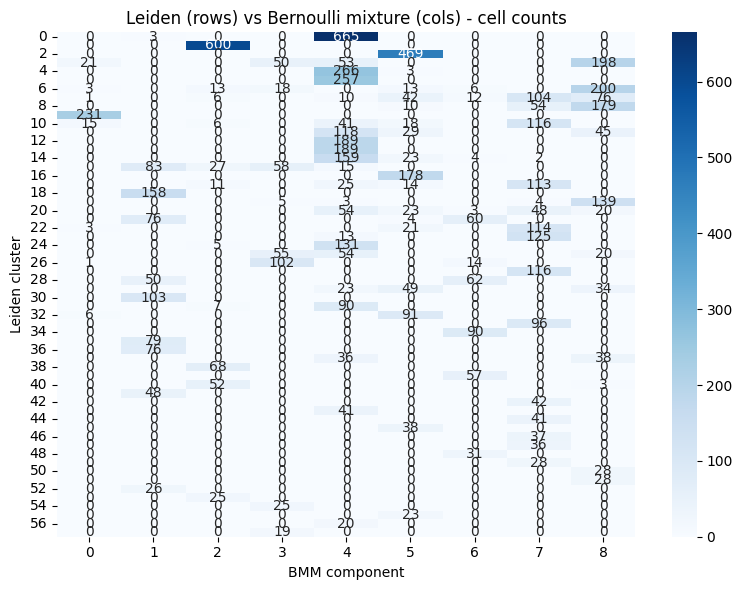

In [ ]:
# Do the methods agree? A high Adjusted Rand Index (ARI) between an unsupervised method
# (Leiden / hierarchical) and the probabilistic BMM means the structure is robust to the
# choice of algorithm - i.e. more likely real biology than an artefact of one method.

# Map each cell's hierarchical-state cluster (computed per cell type) back onto the cell,
# offsetting so epithelial/fibroblast cluster ids do not collide.
df["hier"] = -1
for label, ser in hier_state_clusters.items():
    mask = df.cell_type == label
    offset = df["hier"].max() + 1
    df.loc[mask, "hier"] = df.loc[mask, "binary_state"].map(ser).to_numpy() + offset

print("Adjusted Rand Index between clusterings:")
for a, b in [("leiden", "bmm"), ("leiden", "hier"), ("bmm", "hier")]:
    valid = (df[a] >= 0) & (df[b] >= 0)
    ari = adjusted_rand_score(df.loc[valid, a], df.loc[valid, b])
    print(f"  {a:>6} vs {b:<6}: ARI = {ari:.3f}")

plt.figure(figsize=(8, 6))
sns.heatmap(pd.crosstab(df["leiden"], df["bmm"]), annot=True, fmt="d", cmap="Blues")
plt.title("Leiden (rows) vs Bernoulli mixture (cols) - cell counts")
plt.xlabel("BMM component"); plt.ylabel("Leiden cluster")
plt.tight_layout(); plt.show()


## 3. Neighbourhood analysis

We now describe each cell by its **local micro-environment** rather than its own genes:
the cell-type composition of its spatial neighbours, how many neighbours express each
gene, the **Shannon entropy** of the neighbourhood (diversity), and the **local
density**. Clustering these neighbourhood vectors defines recurring tissue **niches**,
which we relate back to gene state - and we then test whether whole gene states
(e.g. `1_4_7` vs `1_4_8`) co-locate in space.


C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_48472\3703828453.py:32: RuntimeWarning: divide by zero encountered in log
  entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(comp), 0.0), axis=1)
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_48472\3703828453.py:32: RuntimeWarning: invalid value encountered in multiply
  entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(comp), 0.0), axis=1)
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_48472\3703828453.py:32: RuntimeWarning: divide by zero encountered in log
  entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(comp), 0.0), axis=1)
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_48472\3703828453.py:32: RuntimeWarning: invalid value encountered in multiply
  entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(comp), 0.0), axis=1)
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_48472\3703828453.py:32: RuntimeWarning: divide by zero encountered in log
  entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(com

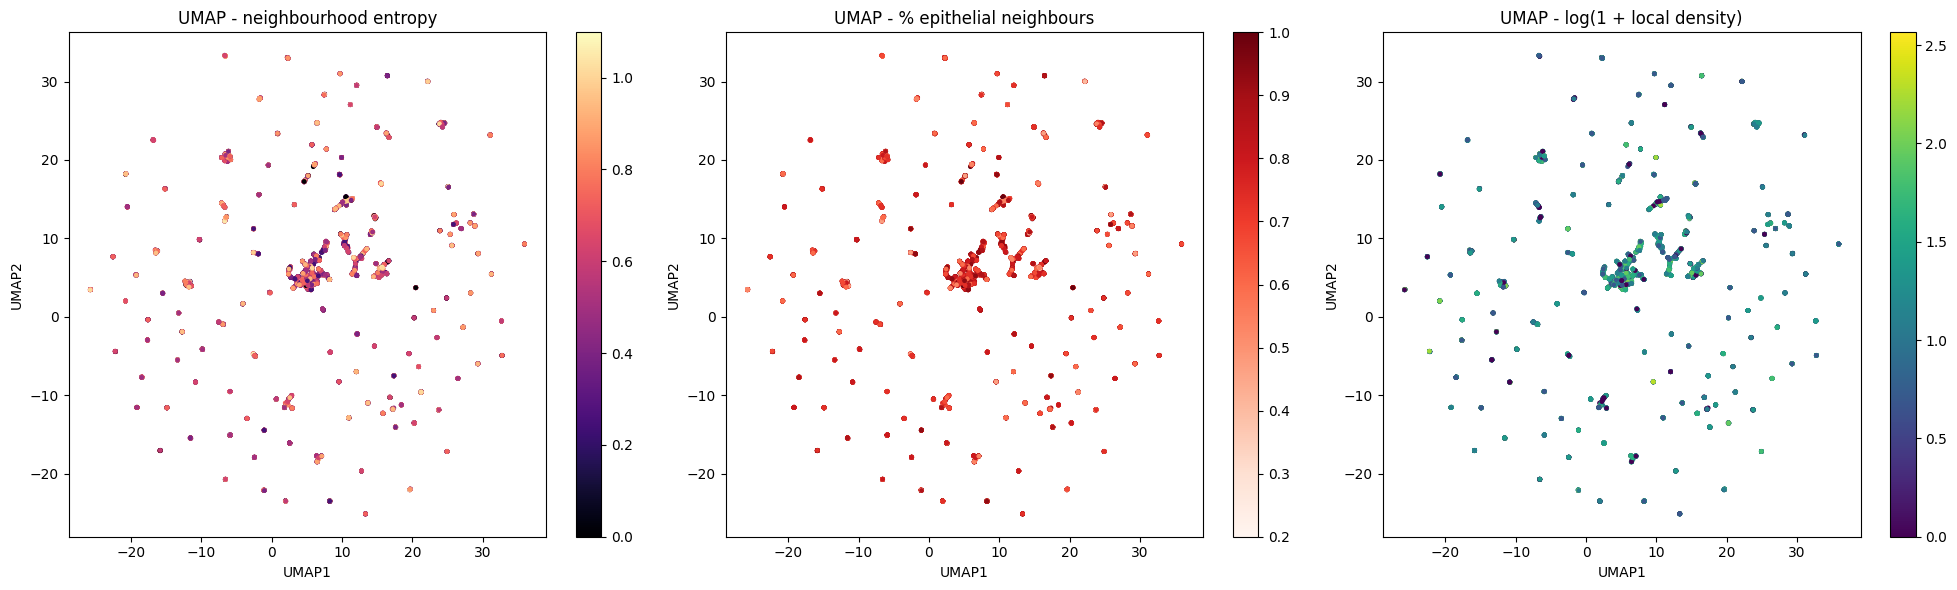

In [ ]:
# NEIGHBOURHOOD ANALYSIS. For every cell we describe its local micro-environment from
# its k nearest spatial neighbours *within the same image* (in microns):
#   - cell-type composition   (% epithelial / fibroblast / unknown)
#   - neighbourhood expression (% of neighbours expressing each gene)
#   - Shannon entropy          (diversity of neighbour cell types)
#   - local density            (number of neighbours within a fixed radius)


K_SPATIAL = 15         # neighbours used for composition / expression
RADIUS_UM = 30.0       # radius (microns) used for the local-density count

ct_dummies = (pd.get_dummies(df["cell_type"])
              .reindex(columns=CT_ORDER, fill_value=0).to_numpy().astype(float))

feat_ct   = np.zeros((len(df), len(CT_ORDER)))
feat_gene = np.zeros((len(df), len(GENES)))
entropy   = np.zeros(len(df))
density   = np.zeros(len(df))

for _, sub in df.groupby(IMAGE_KEY):
    ii = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    tree = cKDTree(coords)
    k = min(K_SPATIAL + 1, len(sub))
    _, nb = tree.query(coords, k=k)
    nb = np.atleast_2d(nb)
    neigh = nb[:, 1:] if nb.shape[1] > 1 else nb   # drop self column
    gneigh = ii[neigh]                             # local -> global indices
    feat_ct[ii]   = ct_dummies[gneigh].mean(axis=1)
    feat_gene[ii] = X[gneigh].mean(axis=1)
    comp = feat_ct[ii]
    entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(comp), 0.0), axis=1)
    density[ii] = np.array([len(x) - 1 for x in tree.query_ball_point(coords, RADIUS_UM)])

nbhd = pd.DataFrame(feat_ct, columns=[f"nb_%{c}" for c in CT_ORDER], index=df.index)
nbhd = pd.concat(
    [nbhd, pd.DataFrame(feat_gene, columns=[f"nb_{g}" for g in GENES], index=df.index)],
    axis=1)
nbhd["nb_entropy"] = entropy
nbhd["nb_density"] = density
df[nbhd.columns] = nbhd

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sc0 = axes[0].scatter(df.umap1, df.umap2, s=6, c=df["nb_entropy"], cmap="magma")
plt.colorbar(sc0, ax=axes[0]); axes[0].set_title("UMAP - neighbourhood entropy")
sc1 = axes[1].scatter(df.umap1, df.umap2, s=6, c=df["nb_%epithelial"], cmap="Reds")
plt.colorbar(sc1, ax=axes[1]); axes[1].set_title("UMAP - % epithelial neighbours")
sc2 = axes[2].scatter(df.umap1, df.umap2, s=6, c=np.log1p(df["nb_density"]), cmap="viridis")
plt.colorbar(sc2, ax=axes[2]); axes[2].set_title("UMAP - log(1 + local density)")
for a in axes:
    a.set_xlabel("UMAP1"); a.set_ylabel("UMAP2")
plt.tight_layout(); plt.show()


c:\Users\taylorhearn\AppData\Local\miniforge3\envs\sequencing\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


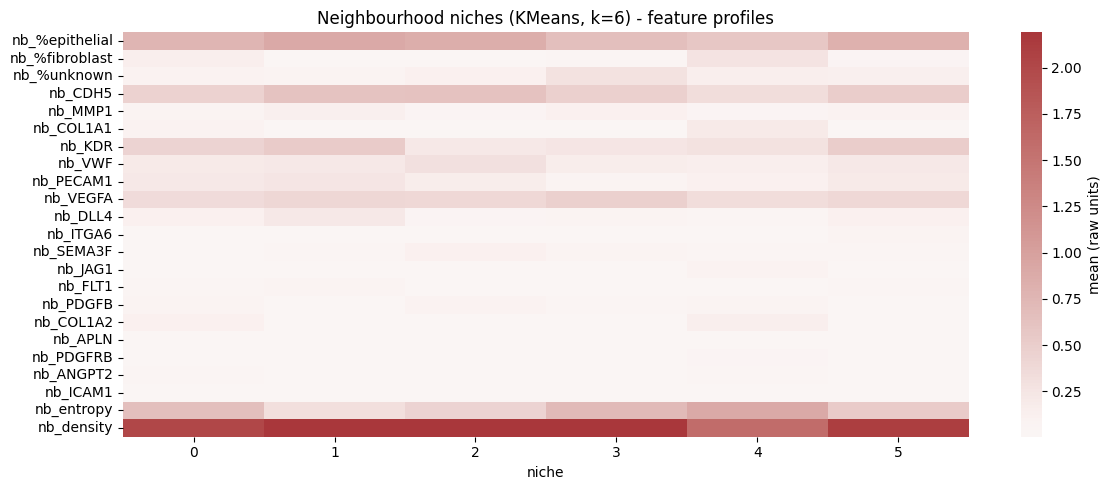

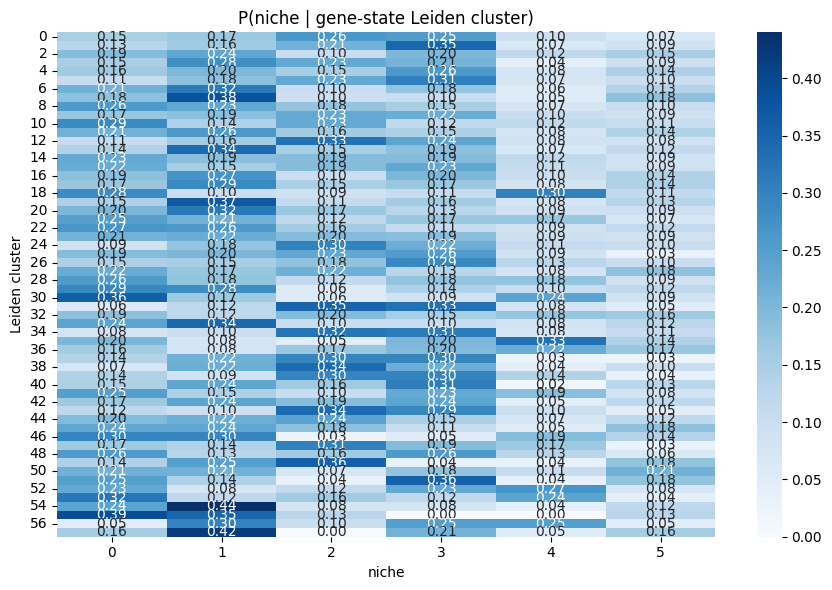

In [ ]:
# Cluster the NEIGHBOURHOODS (not the cells) to define recurring micro-environments
# ("niches"), then ask how a cell's gene state relates to the niche it sits in. This
# links gene state <-> tissue context.

nb_feature_cols = ([f"nb_%{c}" for c in CT_ORDER] +
                   [f"nb_{g}" for g in GENES] + ["nb_entropy", "nb_density"])
Zf = StandardScaler().fit_transform(df[nb_feature_cols].values)

n_niches = 6
df["niche"] = KMeans(n_clusters=n_niches, n_init=10, random_state=0).fit_predict(Zf)

# Mean feature profile of each niche.
niche_profile = df.groupby("niche")[nb_feature_cols].mean()
plt.figure(figsize=(12, 5))
sns.heatmap(niche_profile.T, cmap="vlag", center=0, robust=True,
            cbar_kws={"label": "mean (raw units)"})
plt.title(f"Neighbourhood niches (KMeans, k={n_niches}) - feature profiles")
plt.xlabel("niche"); plt.tight_layout(); plt.show()

# Link gene-state cluster (Leiden) to niche.
plt.figure(figsize=(9, 6))
sns.heatmap(pd.crosstab(df["leiden"], df["niche"], normalize="index"),
            annot=True, fmt=".2f", cmap="Blues")
plt.title("P(niche | gene-state Leiden cluster)")
plt.xlabel("niche"); plt.ylabel("Leiden cluster")
plt.tight_layout(); plt.show()


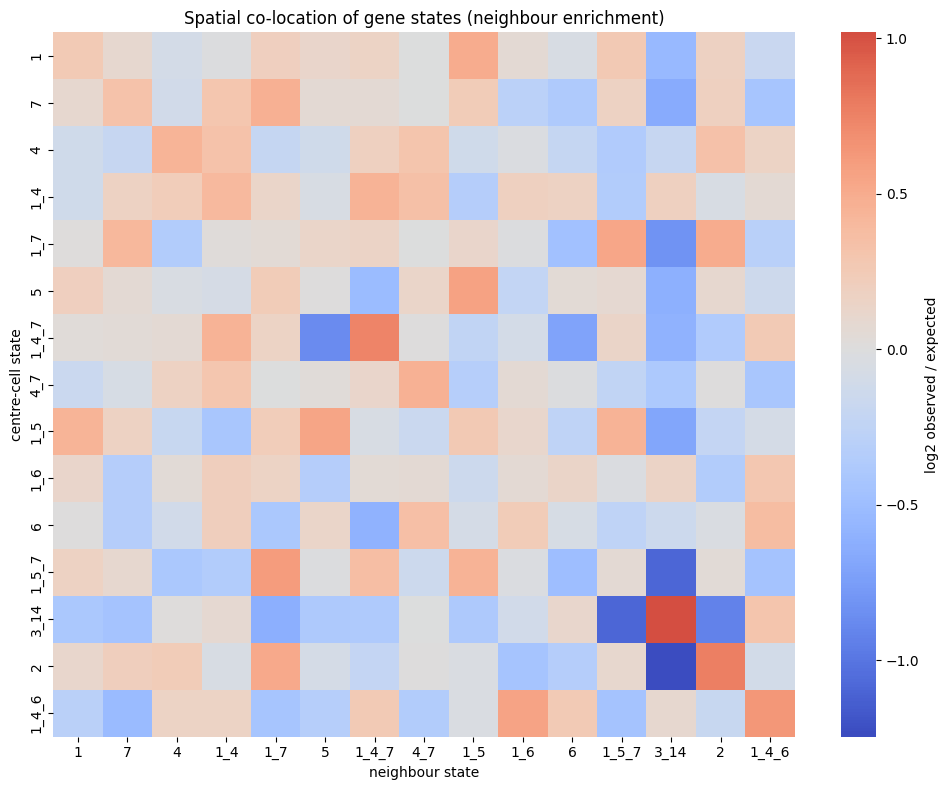

In [22]:
# Do whole gene STATES co-locate in space? Rather than looking at single genes, we
# test complete states: for each of the most common states we measure the fraction of
# a cell's spatial neighbours carrying each other state, then compare to that state's
# global abundance. log2(observed / expected) > 0 means the two states sit together in
# tissue more than chance - so we can ask e.g. whether 1_4_7 and 1_4_8 co-locate.
top_states = df["state_code"].value_counts().head(15).index.tolist()
state_of = df["state_code"].values
global_freq = df["state_code"].value_counts(normalize=True)

obs = pd.DataFrame(0.0, index=top_states, columns=top_states)
cnt = pd.Series(0, index=top_states, dtype=float)
for _, sub in df.groupby(IMAGE_KEY):
    ii = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    tree = cKDTree(coords)
    k = min(K_SPATIAL + 1, len(sub))
    _, nb = tree.query(coords, k=k)
    nb = np.atleast_2d(nb)
    neigh = nb[:, 1:] if nb.shape[1] > 1 else nb
    gneigh = ii[neigh]
    for row, centre_state in zip(gneigh, state_of[ii]):
        if centre_state not in top_states:
            continue
        cnt[centre_state] += 1
        nbr_states = state_of[row]
        for t in top_states:
            obs.loc[centre_state, t] += np.mean(nbr_states == t)

obs = obs.div(cnt.replace(0, np.nan), axis=0)
enrich = np.log2(obs.div(global_freq[top_states], axis=1) + 1e-6)

plt.figure(figsize=(10, 8))
sns.heatmap(enrich, cmap="coolwarm", center=0,
            cbar_kws={"label": "log2 observed / expected"})
plt.title("Spatial co-location of gene states (neighbour enrichment)")
plt.xlabel("neighbour state"); plt.ylabel("centre-cell state")
plt.tight_layout(); plt.show()


## 4. Graph-based approaches

Two complementary graphs:

* **Spatial graph** - nodes = cells, edges = cells within a chosen radius in the same
  image. Used for spatial communities (Leiden), a cell-type **neighbour-enrichment**
  permutation test, and local density.
* **State graph** - nodes = unique gene states, edges connect states differing by a
  single gene (`1` -> `1_4` -> `1_4_7`). Node size = abundance; colour = mean local
  density or % epithelial, revealing how states relate and where they sit in tissue.


Spatial graph: 9,346 edges, 2427 communities


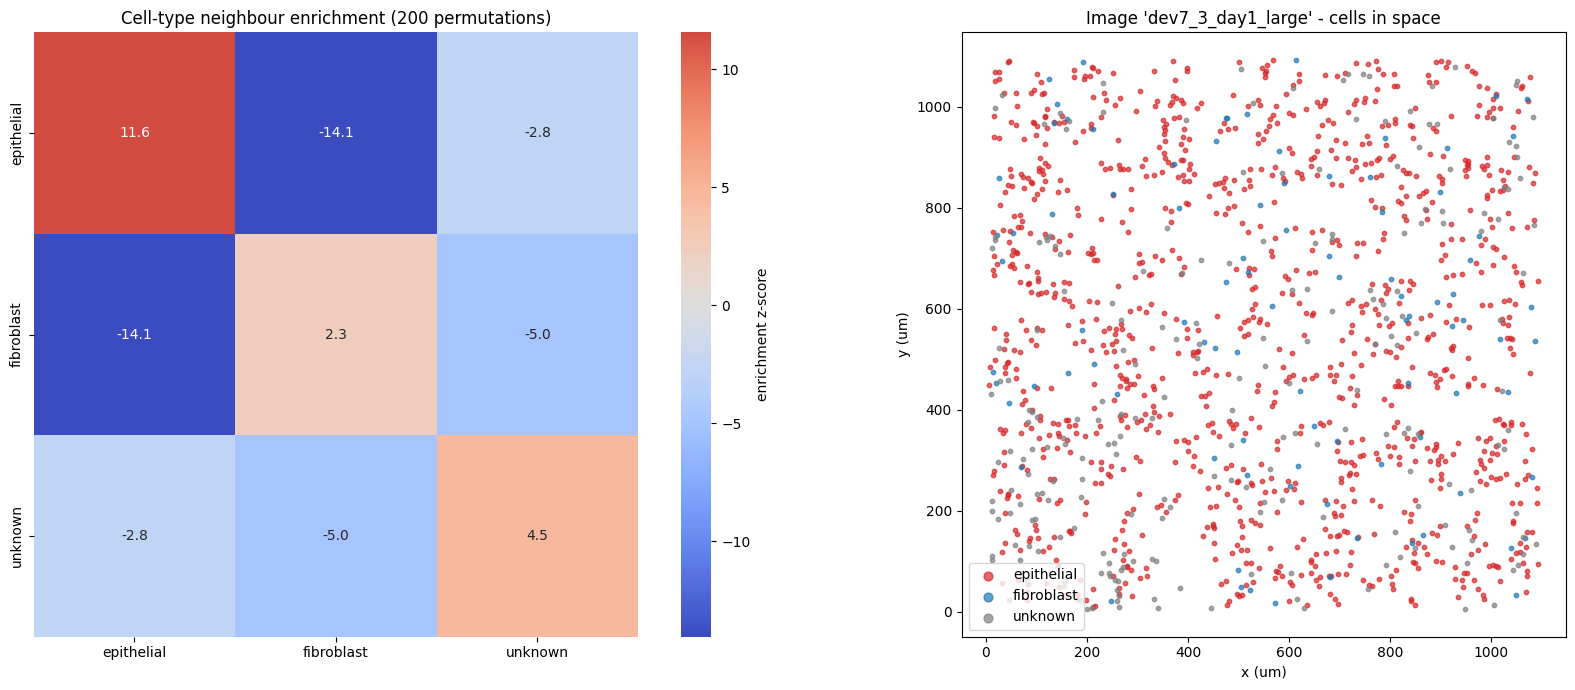

In [ ]:
# GRAPH VIEW 1 - spatial graph. Nodes = cells, edges = cell pairs within RADIUS_UM in
# the SAME image. We (a) detect spatial communities with Leiden, (b) run a cell-type
# neighbour-enrichment permutation test (are epithelial cells next to fibroblasts more
# or less than chance?), and (c) visualise the largest image.

# Build one combined spatial graph (node ids = df row index); edges stay within images.
edges_sp = []
for _, sub in df.groupby(IMAGE_KEY):
    ii = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    tree = cKDTree(coords)
    for a, b in tree.query_pairs(RADIUS_UM):
        edges_sp.append((int(ii[a]), int(ii[b])))

g_sp = ig.Graph(n=len(df), edges=edges_sp)
sp_part = leidenalg.find_partition(g_sp, leidenalg.RBConfigurationVertexPartition,
                                   resolution_parameter=1.0, seed=0)
df["spatial_community"] = np.array(sp_part.membership)
print(f"Spatial graph: {g_sp.ecount():,} edges, "
      f"{df['spatial_community'].nunique()} communities")

# Cell-type neighbour-enrichment permutation test (squidpy-style z-scores).
ct_cat = df["cell_type"].astype("category")
codes = ct_cat.cat.codes.to_numpy()
cats = list(ct_cat.cat.categories)
E = np.array(g_sp.get_edgelist())

def _edge_counts(lbl):
    m = np.zeros((len(cats), len(cats)))
    for u, v in zip(lbl[E[:, 0]], lbl[E[:, 1]]):
        m[u, v] += 1
        m[v, u] += 1
    return m

obs_m = _edge_counts(codes)
rng = np.random.default_rng(0)
perm = np.stack([_edge_counts(rng.permutation(codes)) for _ in range(200)])
z = (obs_m - perm.mean(0)) / (perm.std(0) + 1e-9)
z_df = pd.DataFrame(z, index=cats, columns=cats)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(z_df, cmap="coolwarm", center=0, annot=True, fmt=".1f", square=True,
            ax=axes[0], cbar_kws={"label": "enrichment z-score"})
axes[0].set_title("Cell-type neighbour enrichment (200 permutations)")

# Visualise the largest image in space, coloured by cell type.
big = df[IMAGE_KEY].value_counts().idxmax()
sub = df[df[IMAGE_KEY] == big]
for ct in CT_ORDER:
    s = sub[sub.cell_type == ct]
    axes[1].scatter(s.x_um, s.y_um, s=10, color=CT_COLORS[ct], label=ct, alpha=0.7)
axes[1].set_aspect("equal")
axes[1].legend(markerscale=2)
axes[1].set_title(f"Image '{big}' - cells in space")
axes[1].set_xlabel("x (um)"); axes[1].set_ylabel("y (um)")
plt.tight_layout(); plt.show()


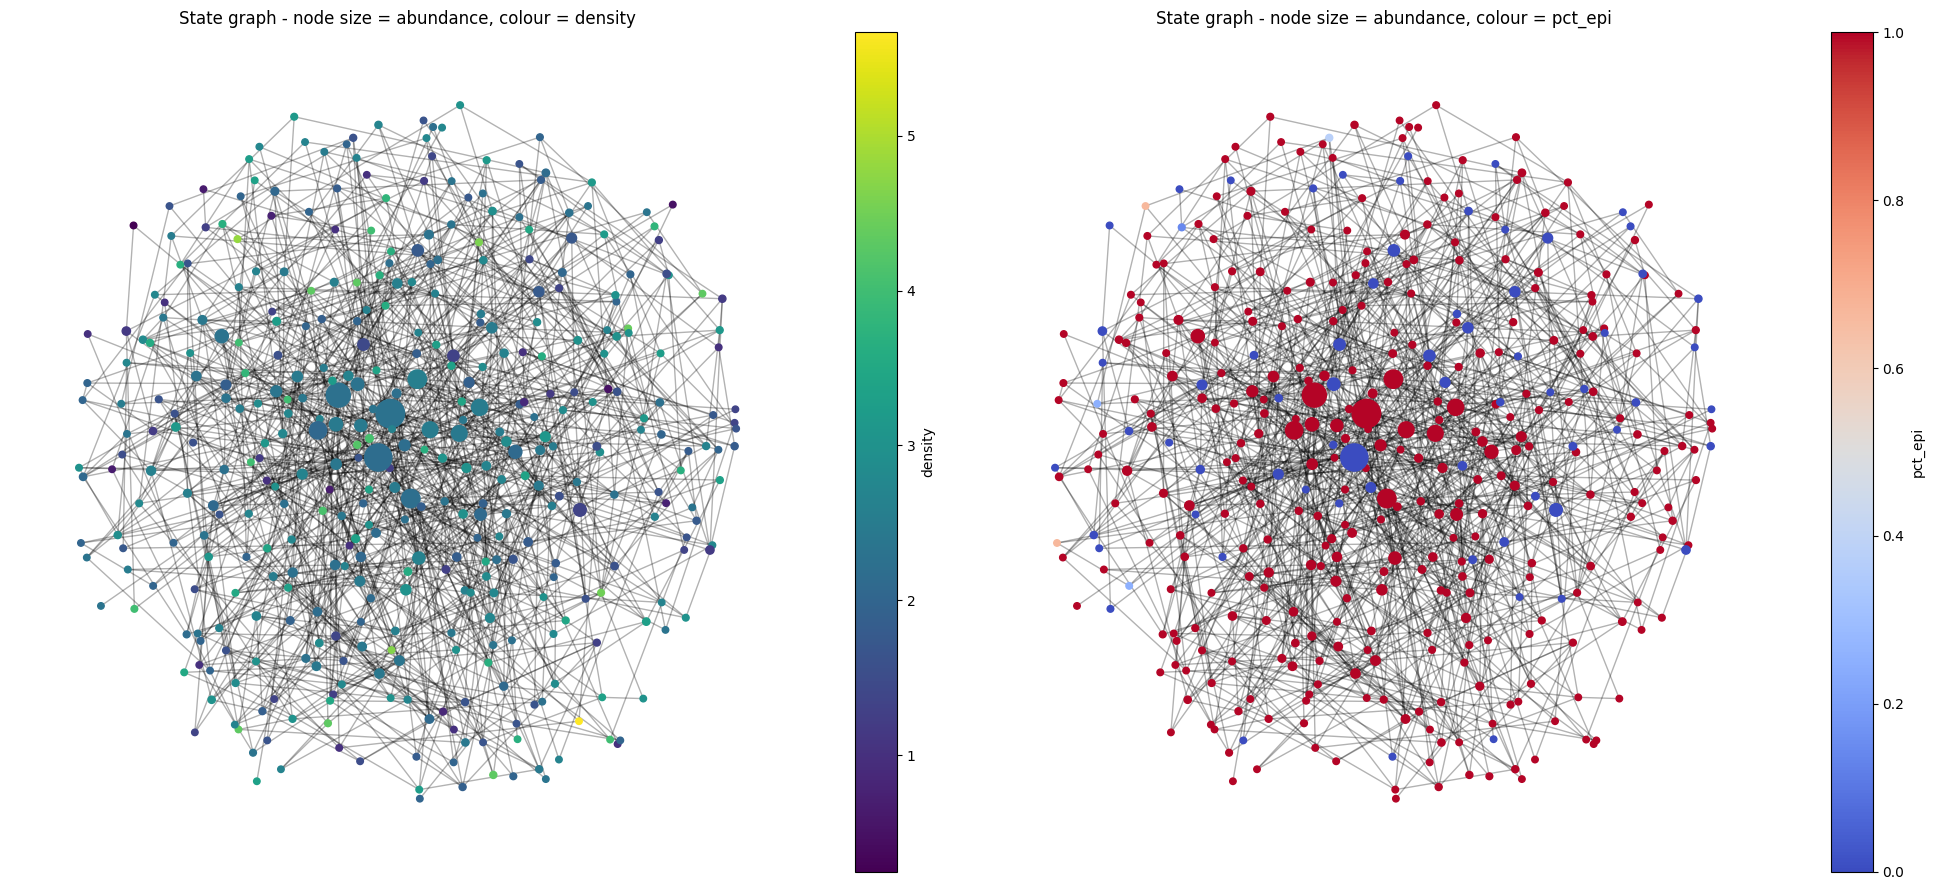

State graph: 394 states, 1105 single-gene transitions


In [ ]:
# GRAPH VIEW 2 - state graph. Nodes = unique recurrent gene states; edges connect
# states differing by exactly ONE gene (Hamming distance 1), so the graph maps how
# states are built up gene-by-gene (e.g. 1 -> 1_4 -> 1_4_7). Node size = abundance;
# we colour once by mean local density and once by % epithelial cells in the state.

state_stats = (
    df.groupby("state_code")
    .agg(n_cells=("state_code", "size"),
         density=("nb_density", "mean"),
         pct_epi=("cell_type", lambda s: (s == "epithelial").mean()))
    .reset_index()
)
# One binary vector per state (states are unique on binary_state).
state_vec = {
    sc: np.array([int(c) for c in df.loc[df.state_code == sc, "binary_state"].iloc[0]])
    for sc in state_stats["state_code"]
}

G = nx.Graph()
for r in state_stats.itertuples():
    G.add_node(r.state_code, n=r.n_cells, density=r.density, pct_epi=r.pct_epi)
for s1, s2 in combinations(state_stats["state_code"].tolist(), 2):
    if int(np.abs(state_vec[s1] - state_vec[s2]).sum()) == 1:
        G.add_edge(s1, s2)

pos = nx.spring_layout(G, seed=0, k=0.5)
sizes = np.array([G.nodes[n]["n"] for n in G], dtype=float)
sizes = 20 + 400 * sizes / sizes.max()

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
for ax, key, cmap in [(axes[0], "density", "viridis"),
                      (axes[1], "pct_epi", "coolwarm")]:
    vals = [G.nodes[n][key] for n in G]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3)
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes,
                                   node_color=vals, cmap=cmap)
    plt.colorbar(nodes, ax=ax, label=key)
    ax.set_title(f"State graph - node size = abundance, colour = {key}")
    ax.axis("off")
plt.tight_layout(); plt.show()

print(f"State graph: {G.number_of_nodes()} states, "
      f"{G.number_of_edges()} single-gene transitions")


## Summary & interpretation

* **Pairwise gene interactions:** significant co-occurring vs mutually-exclusive gene
  pairs (Fisher's exact + FDR), and how these programmes differ between epithelial and
  fibroblast cells.
* **Cell states:** Leiden, hierarchical clustering and a Bernoulli mixture model are
  compared with the Adjusted Rand Index. Agreement across a distance-based method and a
  probabilistic (generative) method argues the subpopulations reflect real biology
  rather than an artefact of any single clustering choice.
* **Neighbourhoods:** cells are grouped into recurring niches by their micro-environment
  (cell-type composition, nearby expression, Shannon diversity, local density), linking
  gene state to tissue context.
* **Graphs:** the spatial cell graph exposes spatial communities and cell-type neighbour
  enrichment; the state graph shows how gene states are built up gene-by-gene and where
  they localise in the tissue.

*Caveats:* cell-type calls are score-based (epithelial vs fibroblast marker sums);
Leiden/KMeans resolutions and the neighbourhood k / radius are tunable and should be
sensitivity-checked; `unknown` cells (no lineage markers) are kept for neighbourhood
context but dominate some niches.


# Initial Data Exploration

All cells:                         21,014
Cells with >=1 transcript:         13,498 (64.2%)
Unique expressed states:           1,761
Recurrent states (> 2 cells):      467
Cells in recurrent states:         11,979 (57.0%)


In [34]:
# Summary table of recurrent states, ranked by frequency.
state_summary = (
    df_recurrent.groupby(["state_code", "binary_state"])
    .size().reset_index(name="n_cells")
    .sort_values("n_cells", ascending=False)
    .reset_index(drop=True)
)
state_summary["pct_all_cells"] = 100 * state_summary["n_cells"] / n_total
state_summary["pct_expressed_cells"] = 100 * state_summary["n_cells"] / len(df_expressed)
state_summary.head(20)


,state_code,binary_state,n_cells,pct_all_cells,pct_expressed_cells
0,1,100000000000000000,1545,7.352241,11.446140
1,7,000000100000000000,734,3.492909,5.437843
2,4,000100000000000000,685,3.259732,5.074826
3,1_4,100100000000000000,505,2.403160,3.741295
4,5,000010000000000000,408,1.941563,3.022670
5,1_7,100000100000000000,341,1.622728,2.526300
6,1_5,100010000000000000,327,1.556105,2.422581
7,1_4_7,100100100000000000,269,1.280099,1.992888
8,1_8,100000010000000000,221,1.051680,1.637280
9,8,000000010000000000,197,0.937470,1.459475


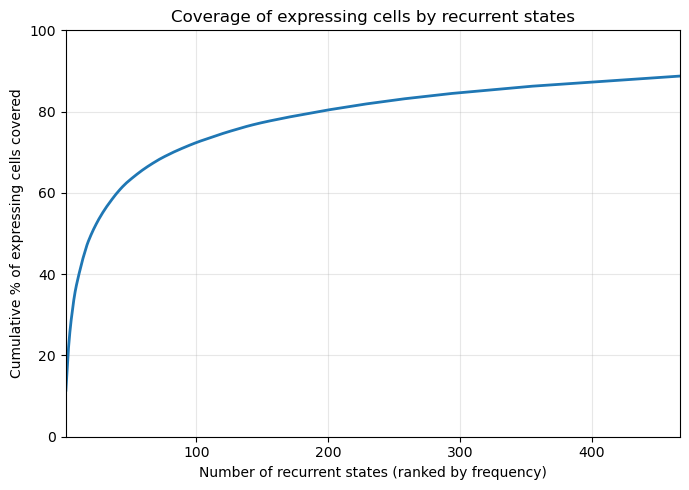

In [35]:
# Coverage: how many recurrent states are needed to account for the expressing cells.
import matplotlib.pyplot as plt

coverage = state_summary.copy()
coverage["rank"] = np.arange(1, len(coverage) + 1)
coverage["cum_pct_expressed"] = 100 * coverage["n_cells"].cumsum() / len(df_expressed)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(coverage["rank"], coverage["cum_pct_expressed"], linewidth=2)
ax.set_xlabel("Number of recurrent states (ranked by frequency)")
ax.set_ylabel("Cumulative % of expressing cells covered")
ax.set_title("Coverage of expressing cells by recurrent states")
ax.set_xlim(1, len(coverage))
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


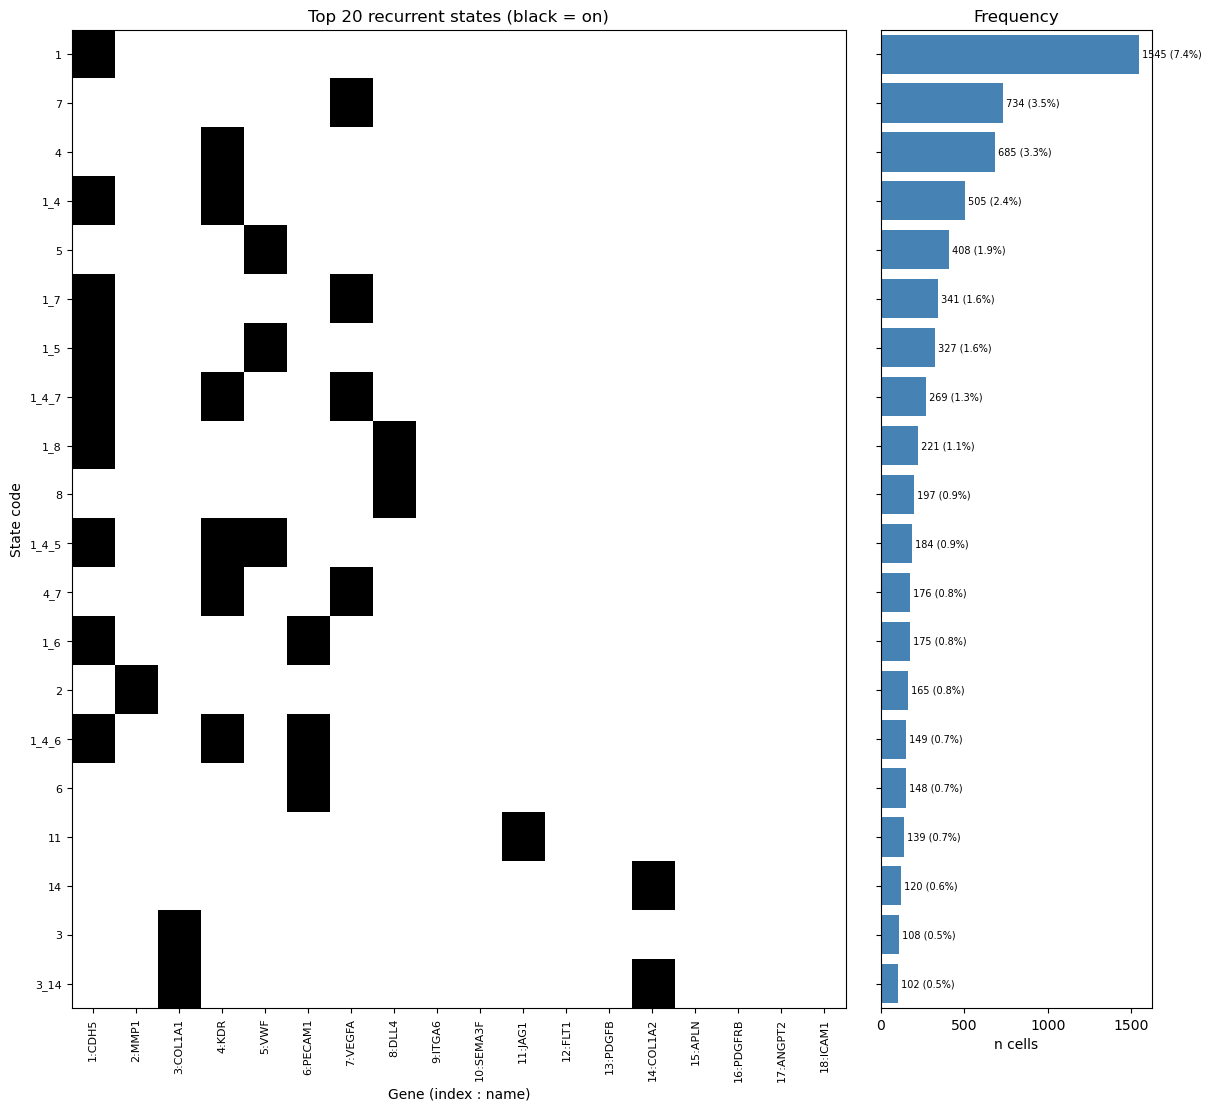

In [38]:
# Recurrent-state heatmap: rows = states, columns = genes 1-18, values = on/off.
# A side annotation shows n_cells and % of all cells, making families (e.g. 1_4,
# 1_4_7, 1_4_11, 1_4_12) easy to spot.
top_n = 20
top_states = state_summary.head(top_n).copy()

state_onoff = pd.DataFrame(
    [[int(ch) for ch in bs] for bs in top_states["binary_state"]],
    columns=[f"{i + 1}:{g}" for i, g in enumerate(true_gene_columns)],
    index=top_states["state_code"],
)

fig, (ax_hm, ax_bar) = plt.subplots(
    1, 2, figsize=(12, 0.45 * top_n + 2),
    gridspec_kw={"width_ratios": [4, 1.4], "wspace": 0.05}, sharey=True,
    constrained_layout=True,
)

ax_hm.imshow(state_onoff.values, aspect="auto", cmap="Greys", vmin=0, vmax=1)
ax_hm.set_xticks(range(len(state_onoff.columns)))
ax_hm.set_xticklabels(state_onoff.columns, rotation=90, fontsize=8)
ax_hm.set_yticks(range(len(state_onoff.index)))
ax_hm.set_yticklabels(state_onoff.index, fontsize=8)
ax_hm.set_xlabel("Gene (index : name)")
ax_hm.set_ylabel("State code")
ax_hm.set_title(f"Top {top_n} recurrent states (black = on)")

y = np.arange(len(top_states))
ax_bar.barh(y, top_states["n_cells"], color="steelblue")
ax_bar.set_xlabel("n cells")
ax_bar.set_title("Frequency")
for yi, (n, pct) in enumerate(zip(top_states["n_cells"], top_states["pct_all_cells"])):
    ax_bar.text(n, yi, f" {n} ({pct:.1f}%)", va="center", fontsize=7)
ax_bar.set_ylim(ax_hm.get_ylim())  # align bars with heatmap rows
plt.show()



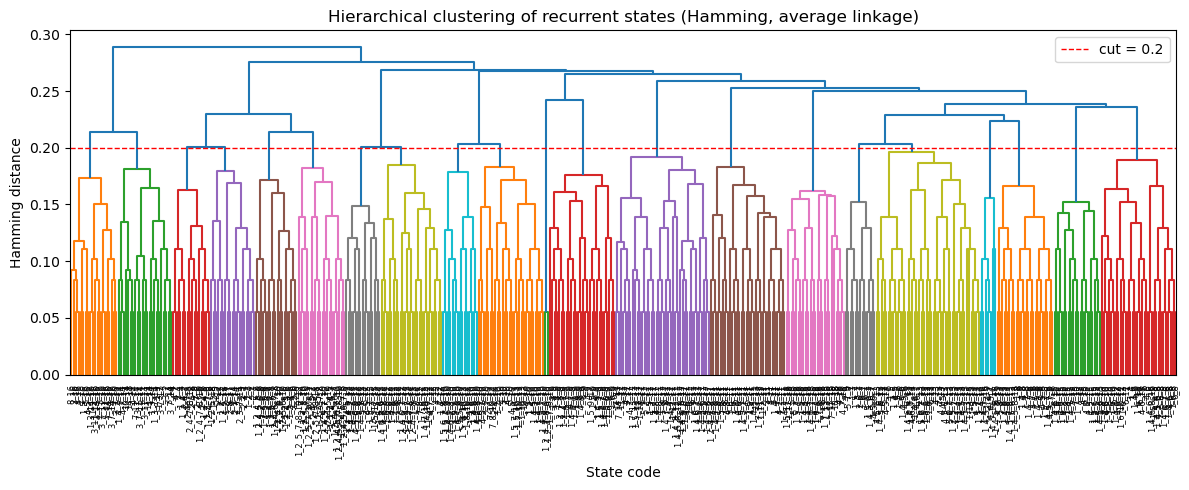

467 recurrent states -> 21 clusters


,cluster_id,n_states,n_cells,example_states,pct_all_cells
0,21,32,2825,"1, 1_4, 1_6, 1_4_6, 6",13.443419
1,17,44,1737,"5, 1_5, 1_4_5, 4_5, 13",8.265918
2,16,13,1342,"7, 1_7, 1_5_7, 5_7, 1_6_7",6.386219
3,3,16,1085,"4, 4_7, 1_2_4_7, 2_4, 1_2_4",5.163225
4,19,24,896,"1_8, 8, 1_4_8, 1_5_8, 1_7_8",4.263824
5,2,23,657,"14, 3, 3_14, 3_7, 3_7_14",3.126487
6,4,19,431,"2, 1_2, 1_2_7, 2_7, 1_2_5",2.051014
7,14,32,409,"11, 1_11, 7_11, 4_11, 1_7_11",1.946321
8,13,40,389,"17, 1_17, 1_4_17, 4_17, 7_17",1.851147
9,10,28,369,"1_10, 10, 7_10, 1_7_10, 1_5_10",1.755972


Saved -> recurrent_states_summary.csv, recurrent_state_clusters.csv


In [37]:
# Cluster the recurrent states using Hamming distance on the 18-gene binary
# vectors with average-linkage hierarchical clustering.
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

hamming_threshold = 0.20  # states within this fractional bit-difference are grouped

state_vectors = np.array(
    [[int(ch) for ch in bs] for bs in state_summary["binary_state"]], dtype=np.uint8
)

dist_condensed = pdist(state_vectors, metric="hamming")
Z = linkage(dist_condensed, method="average")
state_summary["cluster_id"] = fcluster(Z, t=hamming_threshold, criterion="distance")

dist_matrix = squareform(dist_condensed)
np.fill_diagonal(dist_matrix, np.inf)
state_summary["nearest_neighbor_hamming"] = dist_matrix.min(axis=1)

# Per-cluster summary.
cluster_summary = (
    state_summary.groupby("cluster_id")
    .agg(
        n_states=("state_code", "size"),
        n_cells=("n_cells", "sum"),
        example_states=("state_code", lambda s: ", ".join(s.head(5))),
    )
    .reset_index()
    .sort_values("n_cells", ascending=False)
    .reset_index(drop=True)
)
cluster_summary["pct_all_cells"] = 100 * cluster_summary["n_cells"] / n_total

# Dendrogram of recurrent states.
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, labels=state_summary["state_code"].values, color_threshold=hamming_threshold, ax=ax)
ax.axhline(hamming_threshold, color="red", ls="--", lw=1, label=f"cut = {hamming_threshold}")
ax.set_xlabel("State code")
ax.set_ylabel("Hamming distance")
ax.set_title("Hierarchical clustering of recurrent states (Hamming, average linkage)")
ax.legend()
plt.xticks(fontsize=6)
plt.tight_layout()
plt.show()

print(f"{len(state_summary)} recurrent states -> {state_summary['cluster_id'].nunique()} clusters")
display(cluster_summary.head(20))

# Save outputs.
state_summary.to_csv(output_dir / "recurrent_states_summary.csv", index=False)
cluster_summary.to_csv(output_dir / "recurrent_state_clusters.csv", index=False)
print("Saved -> recurrent_states_summary.csv, recurrent_state_clusters.csv")
